# i. Introduction

========================================================================================================

Milestones 2

Nama : Farras Annisa

Batch : HCK-027

Program ini ditujukan untuk membuat model yang dapat memprediksi mental health state.

========================================================================================================

## Dataset Overview

Dataset yang digunakan pada pembuatan model ini terdiri dari:

- **User_ID** : ID unik dari setiap responden  
- **Age** : Umur dari setiap responden.
- **Gender** : Jenis kelamin setiap responden yang dibagi menjadi 3 (Male, Female, Others) dimana Others adalah responden yang tidak mau menyebutkan (Prefer Not To Say).              
- **Technology_Usage_Hours** : Waktu yang digunakan per hari (dalam jam) untuk menggunakan perangkat elektronik (komputer, smartphone, atau tablet) dari setiap responden, per hari (dalam jam).
- **Social_Media_Usage_Hours** : Waktu yang digunakan untuk mengakses platform media sosial (Instagram, Twitter, dan lain-lainnya) dari setiap responden, per hari (dalam jam).
- **Gaming_Hours** : Waktu yang digunakan untuk bermain game, baik di perangkat mobile, konsol, maupun komputer dari setiap responden, per hari (dalam jam).             
- **Screen_Time_Hours** : Waktu yang digunakan untuk menatap layar perangkat elektronik dari setiap responden, per hari (dalam jam).
- **Mental_Health_Status** : Status kesehatan mental dari setiap responden dalam kategori: Poor, Fair, Good, dan Excellent.    
- **Stress_Level** : Tingkat stress responden dalam kategori: Low, Medium, atau High.           
- **Sleep_Hours** : Jam tidur per hari dari setiap responden.
- **Physical_Activity_Hours** : Waktu yang digunakan untuk aktivitas fisik, seperti olahraga, berjalan kaki, atau kegiatan fisik lainnya per hari (dalam jam).   
- **Support_Systems_Access** : Menunjukkan apakah responden memiliki akses ke sistem dukungan sosial atau profesional, seperti keluarga, teman, terapis, atau layanan kesehatan mental (Yes/No).   
- **Work_Environment_Impact** : Persepsi responden terhadap dampak lingkungan kerja mereka terhadap kesehatan mental, dengan kategori: Positive, Neutral, atau Negative.
- **Online_Support_Usage** : Menunjukkan apakah responden menggunakan layanan dukungan kesehatan mental berbasis daring, seperti forum online, aplikasi konseling, atau care group (Yes/No).      

## Problem Statement

Sebagai lembaga yang bergerak dalam bidang kesehatan, khususnya kesehatan mental yang sudah berdiri selama 70 tahun, baru-baru ini NAC mengalami kesulitan dalam menentukan mental health status orang-orang yang datang ke lembaga tersebut. Hal ini dikarenakan faktor-faktor yang memengaruhinya bertambah dengan adanya penggunaan teknologi. Akibatnya NAC sering salah dalam memberikan metode terapi sehingga orang-orang yang datang untuk terapi tidak kunjung membaik. Agar dapat menentukan metode terapi yang tepat kita dapat membuat sebuah 5 model yang nantinya akan diuji untuk menentukan model mana yang dapat memprediksi mental health status yang paling baik.

## Objective

Membantu lembaga NAC yang bergerak dalam bidang kesehatan mental untuk mendiagnosa mental health status.


Memberikan guide untuk pengkategorian mental health status.

# ii. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from scipy import stats
from scipy.stats import chi2_contingency, kendalltau
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, make_scorer, recall_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

Library yang akan dipakai adalah Pandas, Numpy, Scipy, MatPlotLib, Seaborn, Pickle, Sklearn, dan Feature Engine. Berikut ini penjelasan dari masing-masing library:

- Pandas dan Numpy digunakan untuk mengolah data dan filter tabel.

- Scipy digunakan untuk mengimpor modul statistik.

- Matplotlib dan Seaborn digunakan untuk visualisasi data.

- Pickle untuk menyimpan data menjadi file dan memuat data kembali pada proses inference.

- Sklearn digunakan membantu model machine learning.

- Scipy digunakan untuk mengimpor modul statistik.

- XGBoost digunakan untuk mengimpor model XGBoost.

# iv. Data Loading

In [2]:
# Load data menjadi sebuah dataframe
data = pd.read_csv('P1M2_Farras_Annisa.csv')

# Membuat copy data
df = data.copy()

In [3]:
# Menambilkan dataframe
df

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
0,USER-00001,23,Female,6.57,6.00,0.68,12.36,Good,Low,8.01,6.71,No,Negative,Yes
1,USER-00002,21,Male,3.01,2.57,3.74,7.61,Poor,High,7.28,5.88,Yes,Positive,No
2,USER-00003,51,Male,3.04,6.14,1.26,3.16,Fair,High,8.04,9.81,No,Negative,No
3,USER-00004,25,Female,3.84,4.48,2.59,13.08,Excellent,Medium,5.62,5.28,Yes,Negative,Yes
4,USER-00005,53,Male,1.20,0.56,0.29,12.63,Good,Low,5.55,4.00,No,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,USER-09996,42,Male,7.05,0.41,0.53,13.90,Good,Medium,7.37,5.02,Yes,Neutral,No
9996,USER-09997,31,Other,3.12,6.79,0.80,1.17,Fair,Medium,8.92,9.78,No,Neutral,Yes
9997,USER-09998,23,Male,4.38,3.98,0.52,7.81,Poor,High,7.59,2.99,No,Positive,No
9998,USER-09999,38,Male,4.44,1.48,3.28,13.95,Poor,Medium,7.26,2.24,Yes,Neutral,Yes


In [4]:
# Cek jumlah target
df['Mental_Health_Status'].value_counts()

Mental_Health_Status
Excellent    2518
Good         2508
Fair         2490
Poor         2484
Name: count, dtype: int64

## Data Exploration

In [5]:
# Cek tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User_ID                   10000 non-null  object 
 1   Age                       10000 non-null  int64  
 2   Gender                    10000 non-null  object 
 3   Technology_Usage_Hours    10000 non-null  float64
 4   Social_Media_Usage_Hours  10000 non-null  float64
 5   Gaming_Hours              10000 non-null  float64
 6   Screen_Time_Hours         10000 non-null  float64
 7   Mental_Health_Status      10000 non-null  object 
 8   Stress_Level              10000 non-null  object 
 9   Sleep_Hours               10000 non-null  float64
 10  Physical_Activity_Hours   10000 non-null  float64
 11  Support_Systems_Access    10000 non-null  object 
 12  Work_Environment_Impact   10000 non-null  object 
 13  Online_Support_Usage      10000 non-null  object 
dtypes: floa

In [6]:
# Cek nama kolom
df.columns.to_list()

['User_ID',
 'Age',
 'Gender',
 'Technology_Usage_Hours',
 'Social_Media_Usage_Hours',
 'Gaming_Hours',
 'Screen_Time_Hours',
 'Mental_Health_Status',
 'Stress_Level',
 'Sleep_Hours',
 'Physical_Activity_Hours',
 'Support_Systems_Access',
 'Work_Environment_Impact',
 'Online_Support_Usage']

In [7]:
# Cek missing value
df.isnull().sum()

User_ID                     0
Age                         0
Gender                      0
Technology_Usage_Hours      0
Social_Media_Usage_Hours    0
Gaming_Hours                0
Screen_Time_Hours           0
Mental_Health_Status        0
Stress_Level                0
Sleep_Hours                 0
Physical_Activity_Hours     0
Support_Systems_Access      0
Work_Environment_Impact     0
Online_Support_Usage        0
dtype: int64

In [8]:
# Menampilkan 10 data awal
df.head(10)

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
0,USER-00001,23,Female,6.57,6.00,0.68,12.36,Good,Low,8.01,6.71,No,Negative,Yes
1,USER-00002,21,Male,3.01,2.57,3.74,7.61,Poor,High,7.28,5.88,Yes,Positive,No
2,USER-00003,51,Male,3.04,6.14,1.26,3.16,Fair,High,8.04,9.81,No,Negative,No
3,USER-00004,25,Female,3.84,4.48,2.59,13.08,Excellent,Medium,5.62,5.28,Yes,Negative,Yes
4,USER-00005,53,Male,1.20,0.56,0.29,12.63,Good,Low,5.55,4.00,No,Positive,Yes
5,USER-00006,58,Male,5.59,5.74,0.11,1.34,Poor,Low,8.61,6.54,Yes,Neutral,Yes
6,USER-00007,63,Female,3.38,2.55,3.79,9.78,Excellent,Medium,8.61,1.34,Yes,Neutral,No
7,USER-00008,51,Female,7.18,4.10,4.74,8.14,Excellent,Medium,7.11,5.27,Yes,Neutral,No
8,USER-00009,57,Other,10.86,4.11,0.08,6.02,Fair,Medium,7.19,5.22,No,Positive,No
9,USER-00010,31,Other,4.30,7.23,0.81,6.87,Excellent,High,5.09,0.47,No,Positive,No


In [9]:
# Menampilkan 10 data akhir
df.tail(10)

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
9990,USER-09991,40,Male,8.91,5.91,4.25,13.73,Good,Low,5.87,7.67,No,Negative,Yes
9991,USER-09992,63,Female,7.32,6.39,0.13,13.57,Good,Low,6.99,7.90,Yes,Negative,Yes
9992,USER-09993,49,Male,1.66,6.36,4.24,4.55,Good,Medium,6.33,0.12,No,Neutral,No
9993,USER-09994,22,Female,11.58,5.42,0.75,11.88,Good,High,5.98,2.08,No,Positive,No
9994,USER-09995,51,Female,10.71,1.89,3.35,8.03,Fair,Medium,7.77,6.87,No,Neutral,No
9995,USER-09996,42,Male,7.05,0.41,0.53,13.90,Good,Medium,7.37,5.02,Yes,Neutral,No
9996,USER-09997,31,Other,3.12,6.79,0.80,1.17,Fair,Medium,8.92,9.78,No,Neutral,Yes
9997,USER-09998,23,Male,4.38,3.98,0.52,7.81,Poor,High,7.59,2.99,No,Positive,No
9998,USER-09999,38,Male,4.44,1.48,3.28,13.95,Poor,Medium,7.26,2.24,Yes,Neutral,Yes
9999,USER-10000,41,Male,2.50,4.80,0.25,8.82,Fair,Low,4.62,5.09,Yes,Positive,Yes


# vi. Feature Engineering part 1

### Cek distribusi data

In [10]:
# Cek distribusi

# Membuat list berdasarkan kolom yang dibutuhkan
explore1 = ['Age', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Sleep_Hours', 'Physical_Activity_Hours']

listexplore1 = []

# Looping untuk menentukan jenis distribusi
for column in explore1:
    listexplore1.append([column, (df[column].skew()), np.where(0.5 >= df[column].skew() >= -0.5, 'normal', 'skewed')])

# Menyimpan dalam bentuk variabel
skewness = pd.DataFrame(columns = ['Nama Kolom', 'Skewness', 'Jenis Distribusi'], data = listexplore1)
skewness

,Nama Kolom,Skewness,Jenis Distribusi
0,Age,0.005154,normal
1,Technology_Usage_Hours,0.018047,normal
2,Social_Media_Usage_Hours,0.010760,normal
3,Gaming_Hours,-0.023540,normal
4,Screen_Time_Hours,0.015484,normal
5,Sleep_Hours,0.004033,normal
6,Physical_Activity_Hours,0.000612,normal


Berdasarkan tabel di atas, semua kolom numerikal berdistribusi normal.

### Cek outlier

In [11]:
# Menghitung upper, lower boundaries, dan persentase outliers

# Membuat list
column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  col = skewness['Nama Kolom'][row]
  # Cek upper and lower boundary
  if skewness['Jenis Distribusi'][row] == 'skewed':
    IQR = df[col].quantile(0.75) - df[col].quantile(0.25)
    lower_boundary = df[col].quantile(0.25) - (IQR * 3)
    upper_boundary = df[col].quantile(0.75) + (IQR * 3)
  else:
    lower_boundary = df[col].mean() - 3* df[col].std()
    upper_boundary = df[col].mean() + 3* df[col].std()

  # Append list
  column.append(col)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(df[df[col] > upper_boundary]) / len(df) * 100) + (len(df[df[col] < lower_boundary]) / len(df) * 100))
  percent_total_outlier.append(totout)

outliers = pd.DataFrame({
    'column': column,
    
    # Membulatkan nilai
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [(percent_total_outlier) for percent_total_outlier in percent_total_outlier]
})
outliers

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,Age,83.28,-0.24,0.0
1,Technology_Usage_Hours,15.98,-3.03,0.0
2,Social_Media_Usage_Hours,10.91,-2.97,0.0
3,Gaming_Hours,6.86,-1.82,0.0
4,Screen_Time_Hours,20.10,-4.15,0.0
5,Sleep_Hours,10.85,2.15,0.0
6,Physical_Activity_Hours,13.72,-3.71,0.0


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,41.518600,13.920217,18.0,29.00,42.000,54.0000,65.0
Technology_Usage_Hours,10000.0,6.474341,3.169022,1.0,3.76,6.425,9.2125,12.0
Social_Media_Usage_Hours,10000.0,3.972321,2.313707,0.0,1.98,3.950,5.9900,8.0
Gaming_Hours,10000.0,2.515598,1.446748,0.0,1.26,2.520,3.7900,5.0
Screen_Time_Hours,10000.0,7.975765,4.042608,1.0,4.52,7.900,11.5000,15.0
Sleep_Hours,10000.0,6.500724,1.450933,4.0,5.26,6.500,7.7600,9.0
Physical_Activity_Hours,10000.0,5.003860,2.905044,0.0,2.49,4.990,7.5400,10.0


Berdasarkan tabel di atas, semua kolom tidak memiliki outlier (persentase 0.0%).

# v. Exploratory Data Analysis

## 1. Bagaimana korelasi antara 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', dengan 'Technology_Usage_Hours'?

Berdasarkan distribusti data, data numerikal berdistribusi normal, oleh karena itu digunakan uji pearson untuk mencari korelasi.

In [13]:
# Looping untuk cek korelasi dengan metode pearson

listEDA1 = ['Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours']
ResultEDA1 = []

for column in listEDA1:
    corr_coef, p_value = stats.pearsonr(df[column], df['Technology_Usage_Hours'])

    if p_value < 0.05:
        status = 'Ada korelasi'
    else:
        status = 'Tidak ada korelasi'

    ResultEDA1.append([column, p_value, corr_coef, status])

# Menampilkan tabel hasil
pd.DataFrame(columns=['Column', 'P-Value', 'Korelasi', 'Keterangan'], data=ResultEDA1)

,Column,P-Value,Korelasi,Keterangan
0,Social_Media_Usage_Hours,0.020345,0.023199,Ada korelasi
1,Gaming_Hours,0.150908,0.014364,Tidak ada korelasi
2,Screen_Time_Hours,0.426868,0.007947,Tidak ada korelasi


Dari tabel, dapat dilihat bahwa ['Social_Media_Usage_Hours' memiliki korelasi dengan 'Technology_Usage_Hours' meskipung sangat lemah.](https://www.researchgate.net/publication/350285411/figure/tbl1/AS:1004162569474058@1616422421528/Interpretation-guidelines-of-correlation-coefficient.png) yang artinya penggunaan Social Media memengaruhi Waktu tidur seseorang. 'Gaming_Hours' dan 'Screen_Time_Hours' tidak memiliki korelasi dengan 'Technology_Usage_Hours'.

## 2. Bagaimana korelasi antara 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Physical_Activity_Hours', 'Technology_Usage_Hours' dengan 'Sleep_Hours'

In [14]:
# Looping untuk cek korelasi dengan metode pearson

listEDA2 = ['Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Physical_Activity_Hours', 'Technology_Usage_Hours']
ResultEDA2 = []

for column in listEDA2:
    corr_coef, p_value = stats.pearsonr(df[column], df['Sleep_Hours'])

    if p_value < 0.05:
        status = 'Ada korelasi'
    else:
        status = 'Tidak ada korelasi'

    ResultEDA2.append([column, p_value, corr_coef, status])

# Menampilkan tabel hasil
pd.DataFrame(columns=['Column', 'P-Value', 'Korelasi', 'Keterangan'], data=ResultEDA2)

,Column,P-Value,Korelasi,Keterangan
0,Social_Media_Usage_Hours,0.656842,0.004443,Tidak ada korelasi
1,Gaming_Hours,0.298728,0.010393,Tidak ada korelasi
2,Screen_Time_Hours,0.263588,-0.011181,Tidak ada korelasi
3,Physical_Activity_Hours,0.317566,-0.009996,Tidak ada korelasi
4,Technology_Usage_Hours,0.326940,-0.009804,Tidak ada korelasi


Berdasarkan tabel di atas 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Physical_Activity_Hours', 'Technology_Usage_Hours' tidak ada korelasi dengan 'Sleep_Hours'

## 3. Apakah ada perbedaan signifikan antara rata-rata 'Technology_Usage_Hours' pada 'Stress_Level' tiap levelnya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/307835201.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanTech = dfEDA3.groupby('Stress_Level')['Technology_Usage_Hours'].mean()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/307835201.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanTech.index, y=meanTech.values, palette='hls')


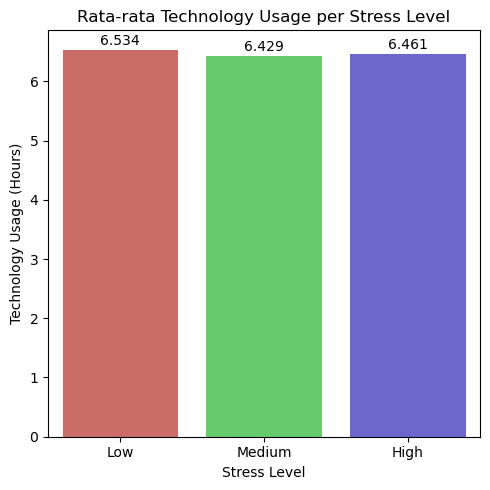

In [15]:
# Mengurutkan 'Stress_Level
df['Stress_Level'] = pd.Categorical(df['Stress_Level'], categories=['Low', 'Medium', 'High'], ordered=True)

dfEDA3 = df[['Technology_Usage_Hours', 'Stress_Level']]

# Plot
plt.figure(figsize=(5,5))
meanTech = dfEDA3.groupby('Stress_Level')['Technology_Usage_Hours'].mean()

sns.barplot(x=meanTech.index, y=meanTech.values, palette='hls')

# Tambahkan label angka di atas bar
for i, val in enumerate(meanTech.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Technology Usage per Stress Level')
plt.ylabel('Technology Usage (Hours)')
plt.xlabel('Stress Level')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Technology_Usage_Hours" tidak ada perbedaan yang signifikan pada tiap 'Stress_Level" nya. Hal ini menunjukkan bahwa rata-rata penggunaan teknologi seperti perangkat elektronik tiap stress level tidak jauh berbeda, tetapi stress level (Low) memiliki rata-rata jam tertinggi.

## 4. Apakah ada perbedaan signifikan antara rata-rata 'Social_Media_Usage_Hours' pada 'Stress_Level' tiap levelnya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3835622503.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanSocmed = dfEDA4.groupby('Stress_Level')['Social_Media_Usage_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3835622503.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanSocmed.index, y=meanSocmed.values, palette='Set2')


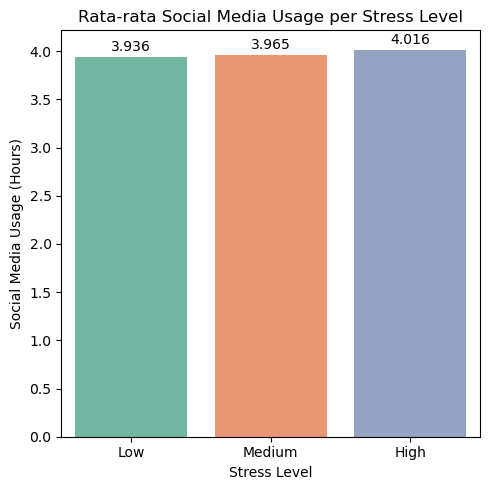

In [16]:
dfEDA4 = df[['Social_Media_Usage_Hours', 'Stress_Level']]

# Plot
plt.figure(figsize=(5,5))
meanSocmed = dfEDA4.groupby('Stress_Level')['Social_Media_Usage_Hours'].mean().sort_index()
sns.barplot(x=meanSocmed.index, y=meanSocmed.values, palette='Set2')


for i, val in enumerate(meanSocmed.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Social Media Usage per Stress Level')
plt.ylabel('Social Media Usage (Hours)')
plt.xlabel('Stress Level')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Social_Media_Usage_Hours" tidak ada perbedaan yang signifikan pada tiap 'Stress_Level" nya. Hal ini menunjukkan bahwa rata-rata penggunaan sosial media tiap stress level tidak jauh berbeda, tetapi stress level (high) memiliki rata-rata jam tertinggi.

## 5. Apakah ada perbedaan signifikan antara rata-rata 'Gaming_Hours' pada 'Stress_Level' tiap levelnya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/4121043608.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanGaming = dfEDA5.groupby('Stress_Level')['Gaming_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/4121043608.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanGaming.index, y=meanGaming.values, palette='Paired')


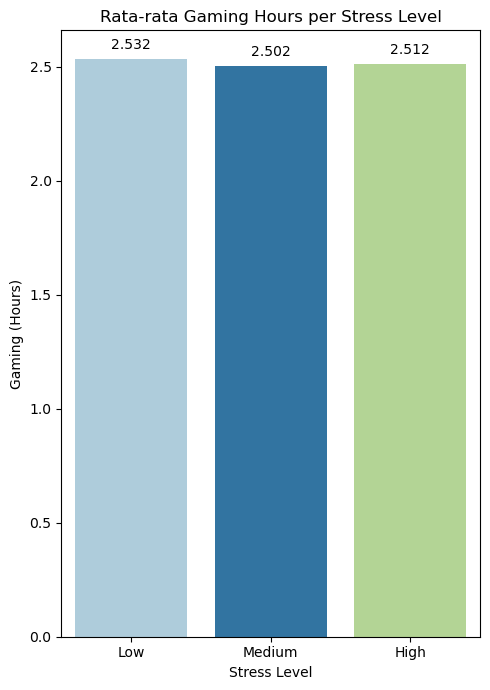

In [17]:
dfEDA5 = df[['Gaming_Hours', 'Stress_Level']]

# Plot
plt.figure(figsize=(5,7))
meanGaming = dfEDA5.groupby('Stress_Level')['Gaming_Hours'].mean().sort_index()
sns.barplot(x=meanGaming.index, y=meanGaming.values, palette='Paired')


for i, val in enumerate(meanGaming.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Gaming Hours per Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Gaming (Hours)')
plt.tight_layout()
plt.show()



Dari visualisasi di atas, rata-rata 'Gaming_Hours" tidak ada perbedaan yang signifikan pada tiap 'Stress_Level" nya. Hal ini menunjukkan bahwa rata-rata bermain game tiap stress level tidak jauh berbeda, tetapi stress level (Low) memiliki rata-rata jam tertinggi.

## 6. Apakah ada perbedaan signifikan antara rata-rata 'Screen_Time_Hours' pada 'Stress_Level' tiap levelnya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3012131239.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanScreen = dfEDA6.groupby('Stress_Level')['Screen_Time_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3012131239.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanScreen.index, y=meanScreen.values, palette='Set1')


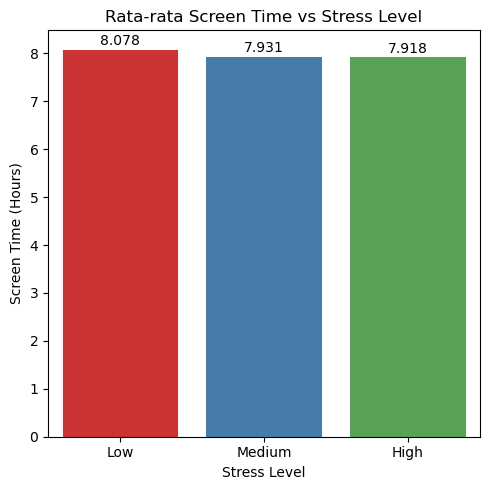

In [18]:
dfEDA6 = df[['Screen_Time_Hours', 'Stress_Level']]

# Plot
plt.figure(figsize=(5,5))
meanScreen = dfEDA6.groupby('Stress_Level')['Screen_Time_Hours'].mean().sort_index()
sns.barplot(x=meanScreen.index, y=meanScreen.values, palette='Set1')


for i, val in enumerate(meanScreen.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Screen Time vs Stress Level')
plt.ylabel('Screen Time (Hours)')
plt.xlabel('Stress Level')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Screen_Time" tidak ada perbedaan yang signifikan pada tiap 'Stress_Level" nya, tetapi stress level (Low) memiliki rata-rata jam tertinggi.

## 7. Apakah ada perbedaan signifikan antara rata-rata 'Sleep_Hours' pada 'Stress_Level' tiap levelnya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/4070788248.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanSleep = dfEDA7.groupby('Stress_Level')['Sleep_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/4070788248.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanSleep.index, y=meanSleep.values, palette='Set3')


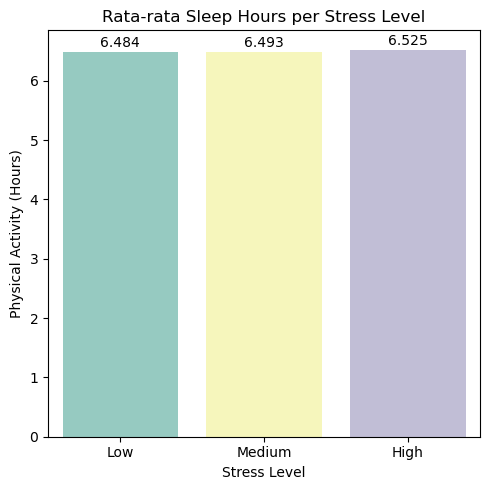

In [19]:
dfEDA7 = df[['Sleep_Hours', 'Stress_Level']]

# Plot
plt.figure(figsize=(5,5))
meanSleep = dfEDA7.groupby('Stress_Level')['Sleep_Hours'].mean().sort_index()
sns.barplot(x=meanSleep.index, y=meanSleep.values, palette='Set3')


for i, val in enumerate(meanSleep.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Sleep Hours per Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Physical Activity (Hours)')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Sleep_Hours" tidak ada perbedaan yang signifikan pada tiap 'Stress_Level" nya, tetapi stress level (High) memiliki rata-rata jam tertinggi.

## 8. Apakah ada perbedaan signifikan antara rata-rata 'Physical_Activity_Hours' pada 'Stress_Level' tiap levelnya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/360217164.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanActivity = dfEDA8.groupby('Stress_Level')['Physical_Activity_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/360217164.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanActivity.index, y=meanActivity.values, palette='OrRd')


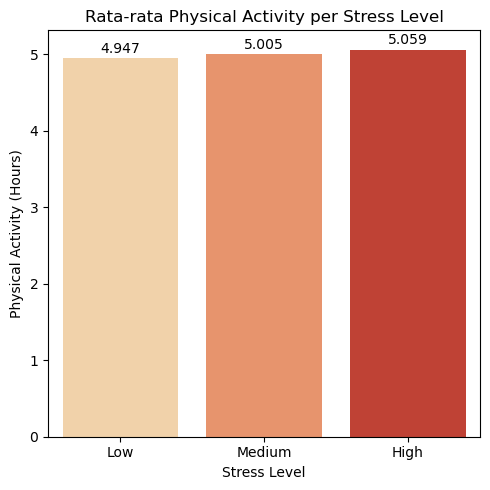

In [20]:
dfEDA8 = df[['Physical_Activity_Hours', 'Stress_Level']]

# Plot
plt.figure(figsize=(5,5))
meanActivity = dfEDA8.groupby('Stress_Level')['Physical_Activity_Hours'].mean().sort_index()
sns.barplot(x=meanActivity.index, y=meanActivity.values, palette='OrRd')


for i, val in enumerate(meanActivity.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Physical Activity per Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Physical Activity (Hours)')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Physical_Activity_Hours" tidak ada perbedaan yang signifikan pada tiap 'Stress_Level" nya, tetapi stress level (High) memiliki rata-rata jam tertinggi.

## 9. Apakah ada perbedaan signifikan antara rata-rata 'Sleep_Hours' pada 'Work_Environment_Impact' tiap pengaruhnya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3159481372.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanSleepWE = dfEDA9.groupby('Work_Environment_Impact')['Sleep_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3159481372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanSleepWE.index, y=meanSleepWE.values, palette='GnBu')


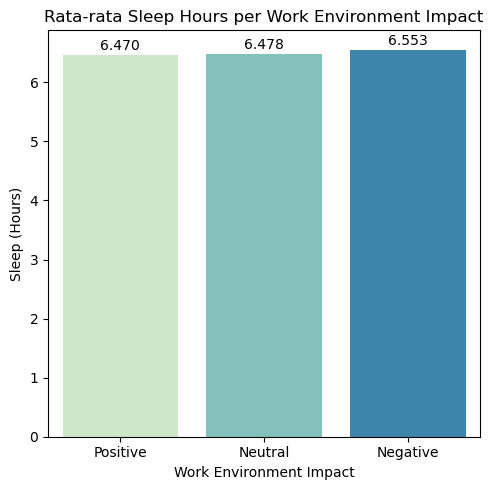

In [21]:
df['Work_Environment_Impact'] = pd.Categorical(df['Work_Environment_Impact'], categories=['Positive', 'Neutral', 'Negative'], ordered=True)

dfEDA9 = df[['Sleep_Hours', 'Work_Environment_Impact']]

# Plot
plt.figure(figsize=(5,5))
meanSleepWE = dfEDA9.groupby('Work_Environment_Impact')['Sleep_Hours'].mean().sort_index()
sns.barplot(x=meanSleepWE.index, y=meanSleepWE.values, palette='GnBu')


for i, val in enumerate(meanSleepWE.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Sleep Hours per Work Environment Impact')
plt.xlabel('Work Environment Impact')
plt.ylabel('Sleep (Hours)')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Sleep_Hours" tidak ada perbedaan yang signifikan pada tiap 'Work_Environment_Impact" nya, tetapi Work Environment Impact (Negative) memiliki rata-rata jam tertinggi.

## 10. Apakah ada perbedaan signifikan antara rata-rata 'Technology_Usage_Hours' pada 'Support_Systems_Access' tiap kategorinya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/2674588013.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanTechSS = dfEDA10.groupby('Support_Systems_Access')['Technology_Usage_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/2674588013.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanTechSS.index, y=meanTechSS.values, palette='RdPu')


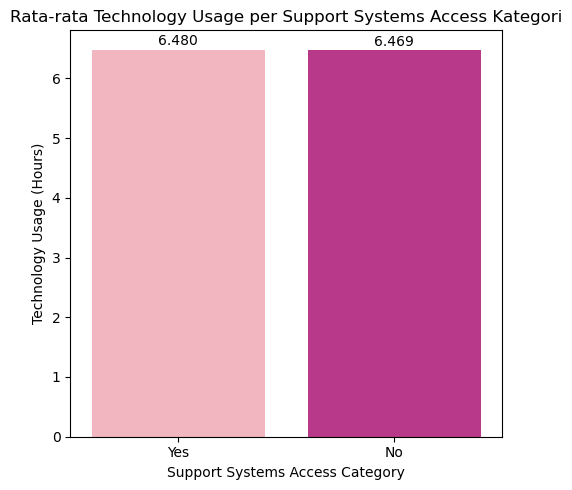

In [22]:
df['Support_Systems_Access'] = pd.Categorical(df['Support_Systems_Access'], categories=['Yes', 'No'], ordered=True)

dfEDA10 = df[['Technology_Usage_Hours', 'Support_Systems_Access']]

# Plot
plt.figure(figsize=(5,5))
meanTechSS = dfEDA10.groupby('Support_Systems_Access')['Technology_Usage_Hours'].mean().sort_index()
sns.barplot(x=meanTechSS.index, y=meanTechSS.values, palette='RdPu')


for i, val in enumerate(meanTechSS.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Technology Usage per Support Systems Access Kategori')
plt.xlabel('Support Systems Access Category')
plt.ylabel('Technology Usage (Hours)')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Technology_Usage_Hours" tidak ada perbedaan yang signifikan pada tiap 'Support_Systems_Access" nya, tetapi orang yang memiliki Support Systems Access (Yes) memiliki rata-rata jam tertinggi.

## 11. Apakah ada perbedaan signifikan antara rata-rata 'Technology_Usage_Hours' pada 'Online_Support_Usage' tiap kategorinya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/2791013680.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanTechOl = dfEDA11.groupby('Online_Support_Usage')['Technology_Usage_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/2791013680.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanTechOl.index, y=meanTechOl.values, palette='YlOrRd')


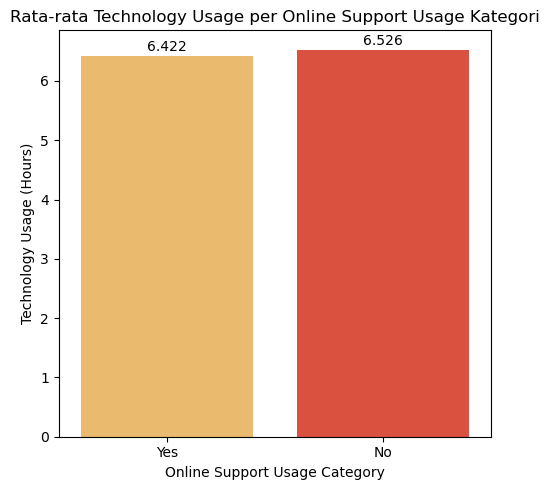

In [23]:
df['Online_Support_Usage'] = pd.Categorical(df['Online_Support_Usage'], categories=['Yes', 'No'], ordered=True)

dfEDA11 = df[['Technology_Usage_Hours', 'Online_Support_Usage']]

# Plot
plt.figure(figsize=(5,5))
meanTechOl = dfEDA11.groupby('Online_Support_Usage')['Technology_Usage_Hours'].mean().sort_index()
sns.barplot(x=meanTechOl.index, y=meanTechOl.values, palette='YlOrRd')


for i, val in enumerate(meanTechOl.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Technology Usage per Online Support Usage Kategori')
plt.xlabel('Online Support Usage Category')
plt.ylabel('Technology Usage (Hours)')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Technology_Usage_Hours" tidak ada perbedaan yang signifikan pada tiap 'Online_Support_Usage" nya, tetapi orang yang tidak memiliki Online Support (No) memiliki rata-rata jam tertinggi.

## 12. Apakah ada perbedaan signifikan antara rata-rata 'Sleep_Hours' pada 'Mental_Health_Status' tiap kategorinya?

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/1816180874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meanTechOl = dfEDA11.groupby('Mental_Health_Status')['Sleep_Hours'].mean().sort_index()
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/1816180874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanTechOl.index, y=meanTechOl.values, palette='YlGn')


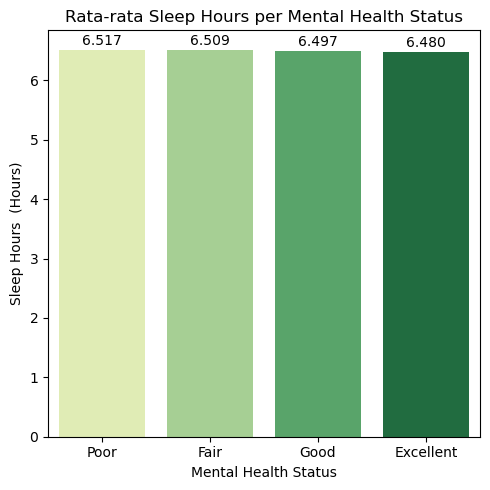

In [24]:
df['Mental_Health_Status'] = pd.Categorical(df['Mental_Health_Status'], categories=['Poor', 'Fair', 'Good', 'Excellent'], ordered=True)

dfEDA11 = df[['Sleep_Hours', 'Mental_Health_Status']]

# Plot
plt.figure(figsize=(5,5))
meanTechOl = dfEDA11.groupby('Mental_Health_Status')['Sleep_Hours'].mean().sort_index()
sns.barplot(x=meanTechOl.index, y=meanTechOl.values, palette='YlGn')


for i, val in enumerate(meanTechOl.values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

plt.title('Rata-rata Sleep Hours per Mental Health Status')
plt.xlabel('Mental Health Status')
plt.ylabel('Sleep Hours  (Hours)')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, rata-rata 'Sleep_Hours" tidak ada perbedaan yang signifikan pada tiap 'Mental_Health_Status" nya, tetapi orang dengan status kesehatan mental 'Poor' memiliki rata-rata jam tertinggi.

## 13. Bagaimana distribusi 'Stress_Level' pada tiap kategori usia 10's - 60's?

In [25]:
# Fungsi kategori usia
def categorize_age(age):
    if 18 <= age <= 19:
        return "10's"
    elif 20 <= age <= 29:
        return "20's"
    elif 30 <= age <= 39:
        return "30's"
    elif 40 <= age <= 49:
        return "40's"
    elif 50 <= age <= 59:
        return "50's"
    elif 60 <= age <= 69:
        return "60's"
    else:
        return 'Other'


dfFilter = (df.assign(AgeGroup=df['Age'].apply(categorize_age)).query("AgeGroup != 'Other'"))


AgeOrder = ["10's", "20's", "30's", "40's", "50's", "60's"]


AgeTotal = dfFilter.groupby('AgeGroup').size().reindex(AgeOrder)

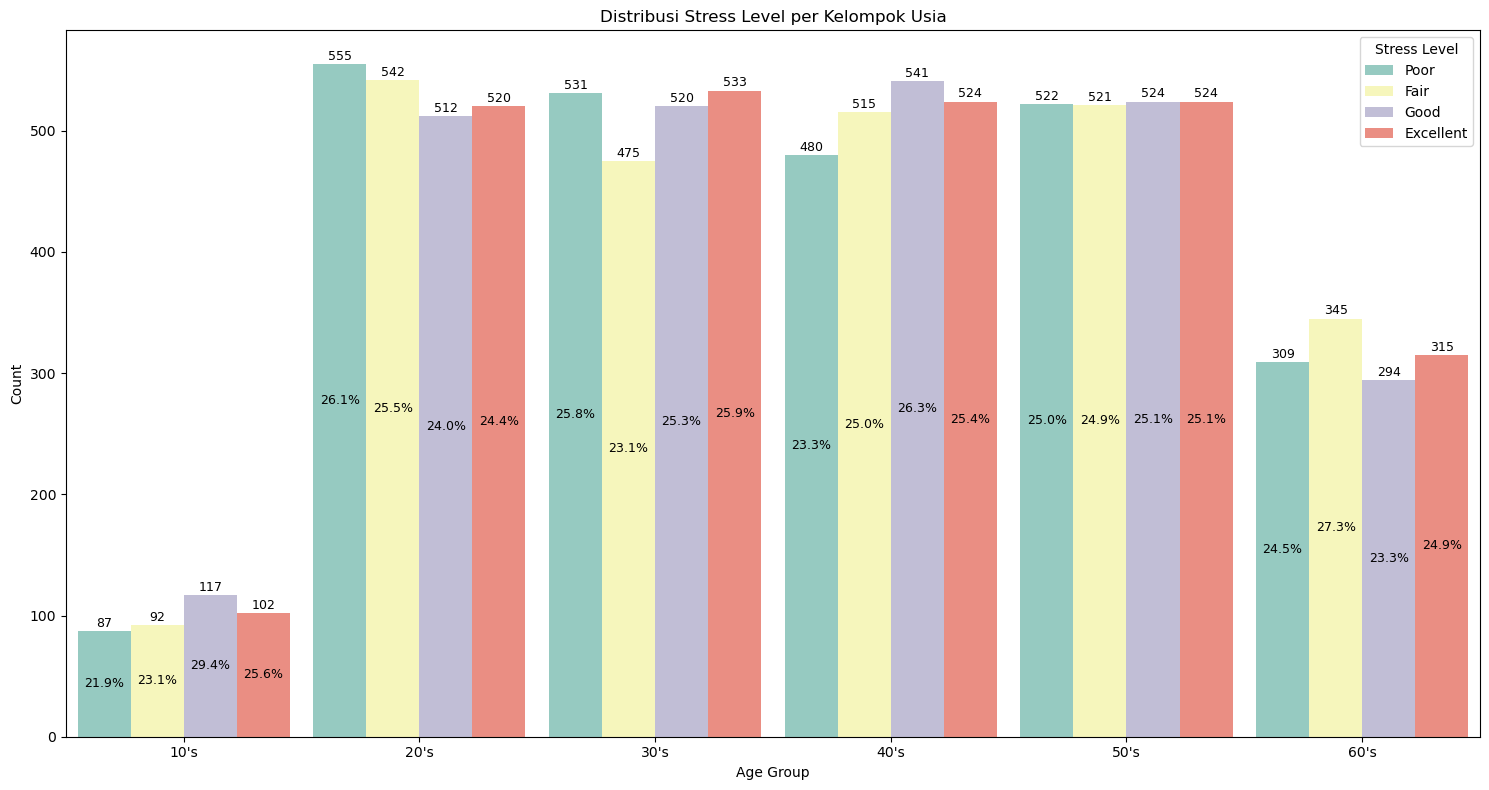

In [26]:
# Plot
plt.figure(figsize=(15, 8))
ax = sns.countplot(
    data=dfFilter,
    x='AgeGroup',
    hue='Mental_Health_Status',
    palette='Set3',
    order=AgeOrder,
    width= 0.9)



for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        AgeGroup = bar.get_label()

        # Dapatkan label kelompok usia berdasarkan posisi x
        xticks = [tick.get_text() for tick in ax.get_xticklabels()]
        x_index = int(round(bar.get_x() + bar.get_width() / 2))
        try:
            AgeLabel = xticks[x_index]
        except IndexError:
            continue


        total = AgeTotal.get(AgeLabel, 1)
        percent = 100 * height / total if total > 0 else 0

 
        ax.text(x, height + 1, f'{int(height)}', ha='center', va='bottom', fontsize=9)

 
        ax.text(x, height / 2, f'{percent:.1f}%', ha='center', va='center', fontsize=9, color='black')

plt.title('Distribusi Stress Level per Kelompok Usia')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Stress Level')
plt.tight_layout()
plt.show()


Dari visualisasi di atas, berdasarkan persentase 'Stress_Level' **Low** terbanyak dimiliki oleh kategori usia 60's, sedangkan **Medium** terbanyak dimiliki oleh kategori usia 20's, dan **High** terbanyak dimiliki oleh kategori usia 10's

## 14. Bagaimana distribusi 'Mental_Health_Status' pada tiap kategori usia 10's - 60's?

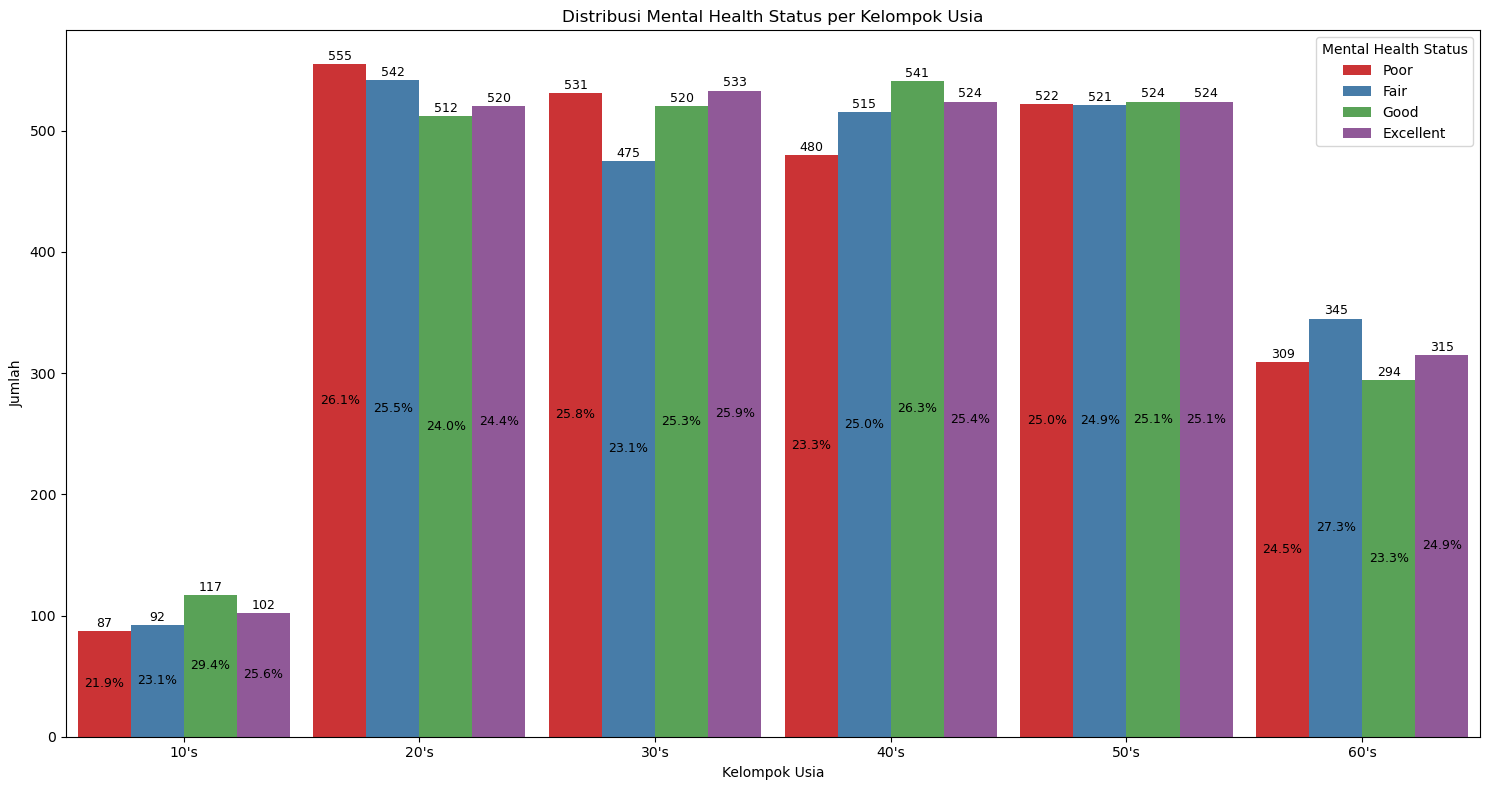

In [27]:
plt.figure(figsize=(15, 8))
ax = sns.countplot(
    data=dfFilter,
    x='AgeGroup',
    hue='Mental_Health_Status',
    palette='Set1',
    order=AgeOrder,
    width= 0.9  
)


for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2

        # Ambil label kelompok usia
        xticks = [tick.get_text() for tick in ax.get_xticklabels()]
        x_index = int(round(bar.get_x() + bar.get_width() / 2))
        try:
            AgeLabel = xticks[x_index]
        except IndexError:
            continue

        total = AgeTotal.get(AgeLabel, 1)
        percent = 100 * height / total if total > 0 else 0

        # Jumlah di atas batang
        ax.text(x, height + 1, f'{int(height)}', ha='center', va='bottom', fontsize=9)
        # Persentase di tengah batang
        ax.text(x, height / 2, f'{percent:.1f}%', ha='center', va='center', fontsize=9, color='black')

plt.title('Distribusi Mental Health Status per Kelompok Usia')
plt.xlabel('Kelompok Usia')
plt.ylabel('Jumlah')
plt.legend(title='Mental Health Status')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, berdasarkan persentase 'Mental_Health_Status' **Poor** terbanyak dimiliki oleh kategori usia 20's, **Fair** terbanyak dimiliki oleh kategori usia 60's, **Good** terbanyak dimiliki oleh kategori usia 10's, dan **Excellent** terbanyak dimiliki oleh kategori usia 30's.

# vi. Feature Engineering part 2

## Split data X (Features) dan Y (Target)

In [28]:
# Split data antara features dan target

# Features values
X = df.drop(columns = ['Mental_Health_Status', 'User_ID'])

# Target values
yRaw = df['Mental_Health_Status']

Drop kolom 'User_ID' dari feature karena tidak mengandung informasi bermakna hanya berupa identitas unik masing-masing responden.

In [29]:
# Features
X

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
0,23,Female,6.57,6.00,0.68,12.36,Low,8.01,6.71,No,Negative,Yes
1,21,Male,3.01,2.57,3.74,7.61,High,7.28,5.88,Yes,Positive,No
2,51,Male,3.04,6.14,1.26,3.16,High,8.04,9.81,No,Negative,No
3,25,Female,3.84,4.48,2.59,13.08,Medium,5.62,5.28,Yes,Negative,Yes
4,53,Male,1.20,0.56,0.29,12.63,Low,5.55,4.00,No,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,42,Male,7.05,0.41,0.53,13.90,Medium,7.37,5.02,Yes,Neutral,No
9996,31,Other,3.12,6.79,0.80,1.17,Medium,8.92,9.78,No,Neutral,Yes
9997,23,Male,4.38,3.98,0.52,7.81,High,7.59,2.99,No,Positive,No
9998,38,Male,4.44,1.48,3.28,13.95,Medium,7.26,2.24,Yes,Neutral,Yes


In [30]:
# Target
yRaw

0            Good
1            Poor
2            Fair
3       Excellent
4            Good
          ...    
9995         Good
9996         Fair
9997         Poor
9998         Poor
9999         Fair
Name: Mental_Health_Status, Length: 10000, dtype: category
Categories (4, object): ['Poor' < 'Fair' < 'Good' < 'Excellent']

In [31]:
# Mapping sesuai kategori mental health status
mapping = {
    'Excellent': 0,
    'Good': 1,
    'Fair': 2,
    'Poor': 3
}

y = yRaw.map(mapping)

In [32]:
y

0       1
1       3
2       2
3       0
4       1
       ..
9995    1
9996    2
9997    3
9998    3
9999    2
Name: Mental_Health_Status, Length: 10000, dtype: category
Categories (4, int64): [3 < 2 < 1 < 0]

## Splitting data Train set dan Test set

In [33]:
# Split data menjadi train set dan test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 30)

print(f"Train Set shape: {X_train.shape}")
print(f"Test Set shape: {X_test.shape}")

Train Set shape: (8000, 12)
Test Set shape: (2000, 12)


## Data Balancing

In [34]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 2182 to 5925
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       8000 non-null   int64   
 1   Gender                    8000 non-null   object  
 2   Technology_Usage_Hours    8000 non-null   float64 
 3   Social_Media_Usage_Hours  8000 non-null   float64 
 4   Gaming_Hours              8000 non-null   float64 
 5   Screen_Time_Hours         8000 non-null   float64 
 6   Stress_Level              8000 non-null   category
 7   Sleep_Hours               8000 non-null   float64 
 8   Physical_Activity_Hours   8000 non-null   float64 
 9   Support_Systems_Access    8000 non-null   category
 10  Work_Environment_Impact   8000 non-null   category
 11  Online_Support_Usage      8000 non-null   category
dtypes: category(4), float64(6), int64(1), object(1)
memory usage: 594.2+ KB


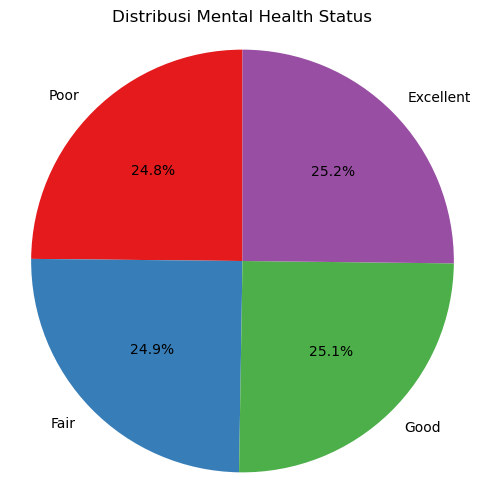

In [35]:
# Hitung jumlah tiap kategori
counts = y.value_counts().sort_index()

# Balik mapping ke nama label
reverse_mapping = {v: k for k, v in mapping.items()}
labels = counts.index.map(reverse_mapping)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,  
    colors=plt.cm.Set1.colors
)
plt.title('Distribusi Mental Health Status')
plt.axis('equal')
plt.show()



Berdasarkan visualisasi jumlah target data tersebut sudah balance karena persentasenya merata. Jadi tidak perlu dilakukan data balancing.

## Cek korelasi antara Kolom Kategorikal dan Numerikal dengan Target

### Cek korelasi antara kolom kategorikal dengan kolom kategorikal

In [36]:
# Daftar fitur kategorikal
listFE2Categorical = ['Gender', 'Stress_Level', 'Support_Systems_Access', 
                      'Work_Environment_Impact', 'Online_Support_Usage']


ResultFE2Categorical = []

# Looping
for col in listFE2Categorical:

    contingency_table = pd.crosstab(X_train[col], df['Mental_Health_Status'])


    chi2, p_value, _, _ = chi2_contingency(contingency_table)


    status = 'Ada korelasi' if p_value < 0.05 else 'Tidak ada korelasi'


    ResultFE2Categorical.append({
        'Feature': col,
        'Chi-Square': round(chi2, 4),
        'p-value': round(p_value, 4),
        'Status': status
    })


pd.DataFrame(ResultFE2Categorical)


,Feature,Chi-Square,p-value,Status
0,Gender,10.2382,0.1150,Tidak ada korelasi
1,Stress_Level,4.5590,0.6015,Tidak ada korelasi
2,Support_Systems_Access,7.6373,0.0541,Tidak ada korelasi
3,Work_Environment_Impact,8.7644,0.1873,Tidak ada korelasi
4,Online_Support_Usage,0.9725,0.8079,Tidak ada korelasi


### Cek korelasi antara kolom numerikal dengan kolom kategorikal

In [37]:
# Daftar list numerikal
listFE2Numerical = ['Age', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Gaming_Hours', 
                    'Screen_Time_Hours', 'Sleep_Hours', 'Physical_Activity_Hours']

# Menyimpan hasil korelasi
ResultFE2Numerical = []

for col in listFE2Numerical:
    corr_coef, p_value = kendalltau(X_train[col], y_train)
    
    # Tentukan status korelasi
    status = 'Ada korelasi' if p_value < 0.05 else 'Tidak ada korelasi'
    
    # Simpan hasil
    ResultFE2Numerical.append({
        'Feature': col,
        'Kendall Tau': round(corr_coef, 4),
        'p-value': round(p_value, 4),
        'Status': status
    })

# Konversi ke DataFrame agar rapi ditampilkan
pd.DataFrame(ResultFE2Numerical)


,Feature,Kendall Tau,p-value,Status
0,Age,-0.0027,0.7485,Tidak ada korelasi
1,Technology_Usage_Hours,-0.0006,0.9462,Tidak ada korelasi
2,Social_Media_Usage_Hours,0.0010,0.9043,Tidak ada korelasi
3,Gaming_Hours,-0.0123,0.1414,Tidak ada korelasi
4,Screen_Time_Hours,-0.0052,0.5343,Tidak ada korelasi
5,Sleep_Hours,0.0082,0.3263,Tidak ada korelasi
6,Physical_Activity_Hours,-0.0012,0.8850,Tidak ada korelasi


## Feature Selection

- Dari uji chi-square di atas semua feature/kolom tidak mempunyai korelasi, akan tetapi semua feature akan tetap saya gunakan karena menurut saya feature memiliki pengaruh terhadap 'Mental_Health_Status'
- Dari uji kendalltau di atas semua feature/kolom tidak mempunyai korelasi, akan tetapi semua feature akan tetap saya gunakan karena menurut saya semua feature memiliki pengaruh terhadap 'Mental_Health_Status.

In [38]:
X_train_Num = X_train[listFE2Numerical]
X_train_Cat = X_train[listFE2Categorical]

X_test_Num = X_test[listFE2Numerical]
X_test_Cat = X_test[listFE2Categorical]

In [39]:
# List sesuai kategori kolom
NumericalColumns = ['Age', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Sleep_Hours', 'Physical_Activity_Hours']
CategoricalColumns = ['Gender', 'Stress_Level', 'Support_Systems_Access', 'Work_Environment_Impact', 'Online_Support_Usage']

## Create Pipeline 

In [40]:
# Variabel duntuk mengurutkan ordinal
StressLevelOrdered = [['Low', 'Medium', 'High']]

# Feature scalling dan encoding
NumericalPipeline = Pipeline([('StandardScaler', StandardScaler())])
CategoricalPipeline = Pipeline([('EncodingOnehot', OneHotEncoder(handle_unknown = 'ignore'))])

# Feature scalling dan encoding pada kolom
PreprocessingPipeline = ColumnTransformer([('PipeNumerical', NumericalPipeline, NumericalColumns),
                                           ('PipeCategorical', CategoricalPipeline, CategoricalColumns)])

# Variabel membuat model
ModelKNN = KNeighborsClassifier()
ModelSVM = SVC()
ModelDTC = DecisionTreeClassifier(random_state=42)
ModelRF = RandomForestClassifier(random_state=42)
ModelXGB = XGBClassifier()



# Pipeline untuk scalling, encoding, dan pemodelan
mModelKNN = Pipeline([('PreprocessingPipe', PreprocessingPipeline),
                  ('KNN', ModelKNN)])

mModelSVM = Pipeline([('PreprocessingPipe', PreprocessingPipeline),
                  ('SVM', ModelSVM)])

mModelDTC = Pipeline([('PreprocessingPipe', PreprocessingPipeline),
                  ('DTC', ModelDTC)])

mModelRF = Pipeline([('PreprocessingPipe', PreprocessingPipeline),
                  ('RF', ModelRF)])

mModelXGB = Pipeline([('PreprocessingPipe', PreprocessingPipeline),
                  ('Boost', ModelXGB)])

[Proses Pipeline sudah mencakup semua proses features scalling, features encoding, dan pemodelan.](https://www.kode.id/courses/take/full-time-data-analytics-phase-1/pdfs/48011079-day-3-pm-algorithm-chains-pipelines) [Scalling menggunakan StandardScaler dikarenakan kolom 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Sleep_Hours', dan 'Physical_Activity_Hours' berdistribusi normal.](https://medium.com/@chandradip93/standard-scaller-6acd9767cb74) [Encoder digunakan untuk mengubah data pada kolom kategorikal 'Age', 'Gender', 'Stress_Level', 'Support_Systems_Access', 'Work_Environment_Impact', 'Online_Support_Usage' menjadi bentuk format numerik yang bisa dipahami oleh model.](https://www.kode.id/courses/take/full-time-data-analytics-phase-1/pdfs/47106282-day-3-pm-feature-engineering-part-2) [ColumnTransformer digunakan untuk menerapkan transformasi data secara selektif ke kolom yang berbeda dalam dataset.](https://www.geeksforgeeks.org/using-columntransformer-in-scikit-learn-for-data-preprocessing/)


- Variabel mModelKNN dibuat untuk menyimpan pipeline pada proses pemodelan K Neighbors.


- Variabel mModelSVM dibuat untuk menyimpan pipeline pada proses pemodelan SVC.
- Variabel mModelDTC dibuat untuk menyimpan pipeline pada proses pemodelan Decision Tree.
- Variabel mModelRF dibuat untuk menyimpan pipeline pada proses pemodelan Random Forest.
- Variabel mModelXGB dibuat untuk menyimpan pipeline pada proses pemodelan XG boosting.

# vii. Model Definition

# vii. Model Training

### KNN

In [41]:
# Training model KNN
mModelKNN.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('PipeNumerical',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('PipeCategorical',
                                                  Pipeline(steps=[('EncodingOnehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Stress_Level',
                                                   'Support_Systems_Access',
                                                   'Work_Environment_Impact',
                                                   'Online_Support_Usage'])])),
                ('KNN', KNeighborsClassifier())])

In [42]:
# Prediksi train dan test set
y_pred_train_mKNN = mModelKNN.predict(X_train)
y_pred_test_mKNN = mModelKNN.predict(X_test)

In [43]:
recall_macro = make_scorer(recall_score, average='macro')

recall_train_cross_val = cross_val_score(
    mModelKNN,
    X_train,
    y_train,
    cv=5,
    scoring=recall_macro
)

print('Recall Score - All - Cross Validation  : ', recall_train_cross_val)
print('Recall Score - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall Score - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall Score - Range of Test-Set       : ',
      (recall_train_cross_val.mean()-recall_train_cross_val.std()), '-',
      (recall_train_cross_val.mean()+recall_train_cross_val.std()))

Recall Score - All - Cross Validation  :  [0.25878524 0.24264738 0.27184915 0.25567635 0.2539598 ]
Recall Score - Mean - Cross Validation :  0.2565835829109123
Recall Score - Std - Cross Validation  :  0.009378802526549036
Recall Score - Range of Test-Set       :  0.24720478038436328 - 0.26596238543746137


### SVM

In [44]:
# Training model SVM
mModelSVM.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('PipeNumerical',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('PipeCategorical',
                                                  Pipeline(steps=[('EncodingOnehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Stress_Level',
                                                   'Support_Systems_Access',
                                                   'Work_Environment_Impact',
                                                   'Online_Support_Usage'])])),
                ('SVM', SVC())])

In [45]:
# Prediksi train dan test set
y_pred_train_mSVM = mModelSVM.predict(X_train)
y_pred_test_mSVM = mModelSVM.predict(X_test)


In [46]:
recall_macro = make_scorer(recall_score, average='macro')

recall_train_cross_val = cross_val_score(
    mModelSVM,
    X_train,
    y_train,
    cv=5,
    scoring=recall_macro
)

print('Recall Score - All - Cross Validation  : ', recall_train_cross_val)
print('Recall Score - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall Score - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall Score - Range of Test-Set       : ',
      (recall_train_cross_val.mean()-recall_train_cross_val.std()), '-',
      (recall_train_cross_val.mean()+recall_train_cross_val.std()))

Recall Score - All - Cross Validation  :  [0.26275733 0.25422784 0.2402823  0.23475531 0.24110558]
Recall Score - Mean - Cross Validation :  0.24662567213968384
Recall Score - Std - Cross Validation  :  0.010292120726245073
Recall Score - Range of Test-Set       :  0.23633355141343876 - 0.2569177928659289


### Decision Tree

In [47]:
# Training model Decision Tree
mModelDTC.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('PipeNumerical',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('PipeCategorical',
                                                  Pipeline(steps=[('EncodingOnehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Stress_Level',
                                                   'Support_Systems_Access',
                                                   'Work_Environment_Impact',
                                                   'Online_Support_Usage'])])),
                ('DTC', DecisionTreeClassifier(random_state=42))])

In [48]:
# Prediksi train dan test set
y_pred_train_mDTC = mModelDTC.predict(X_train)
y_pred_test_mDTC = mModelDTC.predict(X_test)

In [49]:
recall_macro = make_scorer(recall_score, average='macro')

recall_train_cross_val = cross_val_score(
    mModelDTC,
    X_train,
    y_train,
    cv=5,
    scoring=recall_macro
)

print('Recall Score - All - Cross Validation  : ', recall_train_cross_val)
print('Recall Score - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall Score - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall Score - Range of Test-Set       : ',
      (recall_train_cross_val.mean()-recall_train_cross_val.std()), '-',
      (recall_train_cross_val.mean()+recall_train_cross_val.std()))

Recall Score - All - Cross Validation  :  [0.2343798  0.23073384 0.23992656 0.22195908 0.24233881]
Recall Score - Mean - Cross Validation :  0.23386761786247673
Recall Score - Std - Cross Validation  :  0.007216203454304848
Recall Score - Range of Test-Set       :  0.22665141440817188 - 0.24108382131678158


### Random Forest

In [50]:
# Training model Random Forest
mModelRF.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('PipeNumerical',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('PipeCategorical',
                                                  Pipeline(steps=[('EncodingOnehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Stress_Level',
                                                   'Support_Systems_Access',
                                                   'Work_Environment_Impact',
                                                   'Online_Support_Usage'])])),
                ('RF', RandomForestClassifier(random_state=42))])

In [51]:
# Prediksi train dan test set
y_pred_train_mRF = mModelRF.predict(X_train)
y_pred_test_mRF = mModelRF.predict(X_test)

In [52]:
recall_macro = make_scorer(recall_score, average='macro')

recall_train_cross_val = cross_val_score(
    mModelRF,
    X_train,
    y_train,
    cv=5,
    scoring=recall_macro
)

print('Recall Score - All - Cross Validation  : ', recall_train_cross_val)
print('Recall Score - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall Score - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall Score - Range of Test-Set       : ',
      (recall_train_cross_val.mean()-recall_train_cross_val.std()), '-',
      (recall_train_cross_val.mean()+recall_train_cross_val.std()))

Recall Score - All - Cross Validation  :  [0.24676908 0.266692   0.25398258 0.22534881 0.26027338]
Recall Score - Mean - Cross Validation :  0.25061316960252816
Recall Score - Std - Cross Validation  :  0.014256689787777341
Recall Score - Range of Test-Set       :  0.23635647981475083 - 0.2648698593903055


### Boosting

In [53]:
mModelXGB.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('PipeNumerical',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('PipeCategorical',
                                                  Pipeline(steps=[('EncodingOnehot',
                                                                   OneHotEncoder(handle_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [54]:
# Prediksi train dan test set
y_pred_train_mXGB = mModelXGB.predict(X_train)
y_pred_test_mXGB = mModelXGB.predict(X_test)

In [55]:
recall_macro = make_scorer(recall_score, average='macro')

recall_train_cross_val = cross_val_score(
    mModelXGB,
    X_train,
    y_train,
    cv=5,
    scoring=recall_macro
)

print('Recall Score - All - Cross Validation  : ', recall_train_cross_val)
print('Recall Score - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall Score - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall Score - Range of Test-Set       : ',
      (recall_train_cross_val.mean()-recall_train_cross_val.std()), '-',
      (recall_train_cross_val.mean()+recall_train_cross_val.std()))

Recall Score - All - Cross Validation  :  [0.24001718 0.23681048 0.24378348 0.22678    0.26009595]
Recall Score - Mean - Cross Validation :  0.2414974198826255
Recall Score - Std - Cross Validation  :  0.010880186905835027
Recall Score - Range of Test-Set       :  0.23061723297679046 - 0.2523776067884605


# ix. Model Evaluation

## KNN

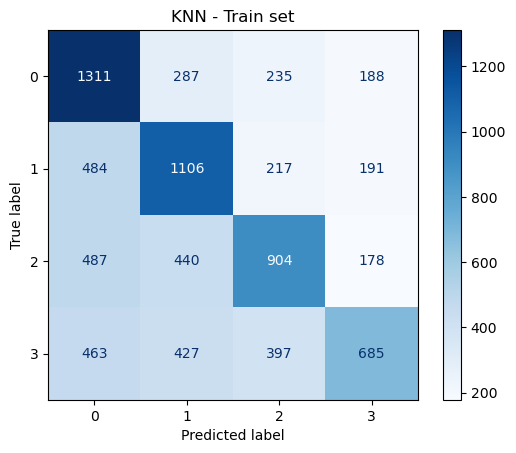

Classification Report - Train Set:
              precision    recall  f1-score   support

           0       0.48      0.65      0.55      2021
           1       0.49      0.55      0.52      1998
           2       0.52      0.45      0.48      2009
           3       0.55      0.35      0.43      1972

    accuracy                           0.50      8000
   macro avg       0.51      0.50      0.49      8000
weighted avg       0.51      0.50      0.49      8000



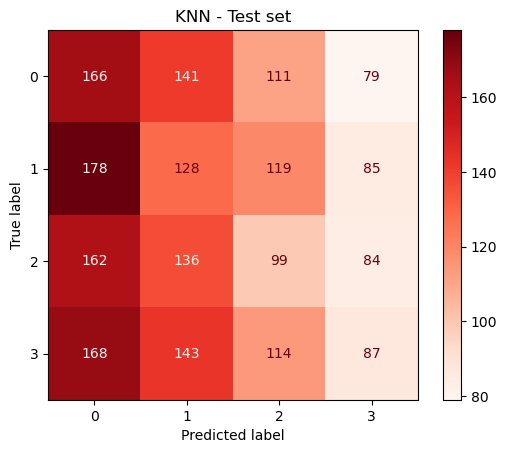

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.25      0.33      0.28       497
           1       0.23      0.25      0.24       510
           2       0.22      0.21      0.21       481
           3       0.26      0.17      0.21       512

    accuracy                           0.24      2000
   macro avg       0.24      0.24      0.24      2000
weighted avg       0.24      0.24      0.24      2000



In [56]:
# Hitung confusion matrix untuk train dan test
CMTrain = confusion_matrix(y_train, y_pred_train_mKNN)
CMTest = confusion_matrix(y_test, y_pred_test_mKNN)

# Plot confusion matrix untuk train
disp_train = ConfusionMatrixDisplay(confusion_matrix=CMTrain)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("KNN - Train set")
plt.show()

print("Classification Report - Train Set:")
print(classification_report(y_train, y_pred_train_mKNN))


# Plot confusion matrix untuk test
disp_test = ConfusionMatrixDisplay(confusion_matrix=CMTest)
disp_test.plot(cmap=plt.cm.Reds)
plt.title("KNN - Test set")
plt.show()

print("Classification Report - Test Set:")
print(classification_report(y_test, y_pred_test_mKNN))


Dari Classification Report Model KNN di atas, di dapatkan didapatkan nilai recall dimana mengurangi False Negative (memprediksi orang sehat (fair, good,excellent) aktualnya sakit (poor)). Nilai pada train = 0.35 dan test = 0.17. Hal ini menunjukkan bahwa model overfit.

## SVM

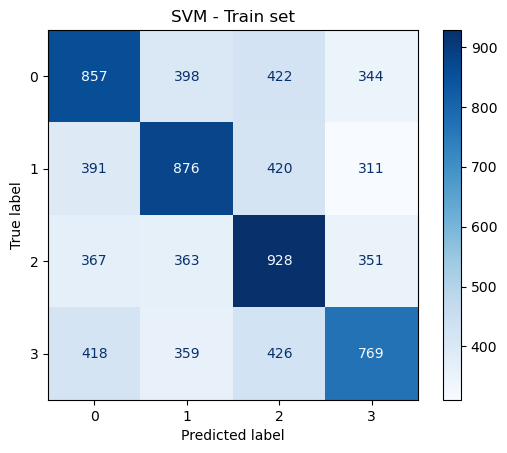

Classification Report - Train Set:
              precision    recall  f1-score   support

           0       0.42      0.42      0.42      2021
           1       0.44      0.44      0.44      1998
           2       0.42      0.46      0.44      2009
           3       0.43      0.39      0.41      1972

    accuracy                           0.43      8000
   macro avg       0.43      0.43      0.43      8000
weighted avg       0.43      0.43      0.43      8000



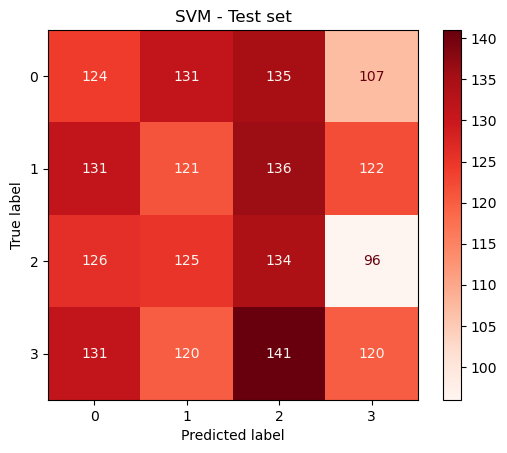

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.24      0.25      0.25       497
           1       0.24      0.24      0.24       510
           2       0.25      0.28      0.26       481
           3       0.27      0.23      0.25       512

    accuracy                           0.25      2000
   macro avg       0.25      0.25      0.25      2000
weighted avg       0.25      0.25      0.25      2000



In [57]:
# Hitung confusion matrix untuk train dan test
CMTrain = confusion_matrix(y_train, y_pred_train_mSVM)
CMTest = confusion_matrix(y_test, y_pred_test_mSVM)

# Plot confusion matrix untuk train
disp_train = ConfusionMatrixDisplay(confusion_matrix=CMTrain)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("SVM - Train set")
plt.show()

print("Classification Report - Train Set:")
print(classification_report(y_train, y_pred_train_mSVM))


# Plot confusion matrix untuk test
disp_test = ConfusionMatrixDisplay(confusion_matrix=CMTest)
disp_test.plot(cmap=plt.cm.Reds)
plt.title("SVM - Test set")
plt.show()

print("Classification Report - Test Set:")
print(classification_report(y_test, y_pred_test_mSVM))


Dari Classification Report Model SVM di atas, di dapatkan didapatkan nilai recall dimana mengurangi False Negative (memprediksi orang sehat (fair, good,excellent) aktualnya sakit (poor)). Nilai pada train = 0.39 dan test = 0.23. Hal ini menunjukkan bahwa model overfit.

## Decision Tree

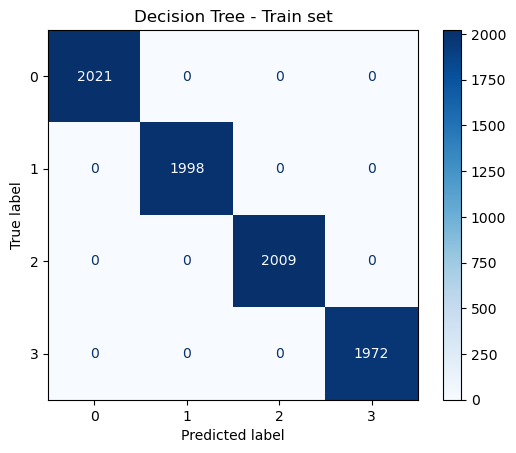

Classification Report - Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2021
           1       1.00      1.00      1.00      1998
           2       1.00      1.00      1.00      2009
           3       1.00      1.00      1.00      1972

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



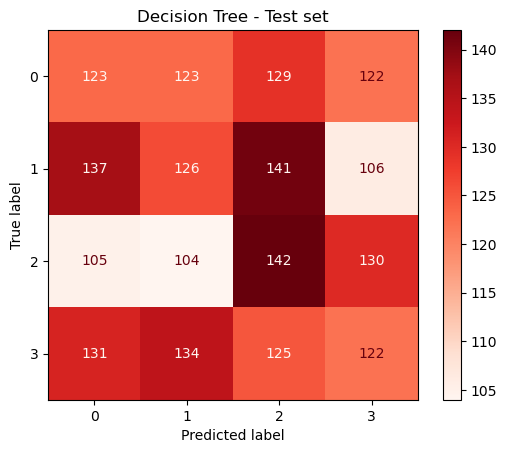

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.25      0.25      0.25       497
           1       0.26      0.25      0.25       510
           2       0.26      0.30      0.28       481
           3       0.25      0.24      0.25       512

    accuracy                           0.26      2000
   macro avg       0.26      0.26      0.26      2000
weighted avg       0.26      0.26      0.26      2000



In [58]:
# Hitung confusion matrix untuk train dan test
CMTrain = confusion_matrix(y_train, y_pred_train_mDTC)
CMTest = confusion_matrix(y_test, y_pred_test_mDTC)

# Plot confusion matrix untuk train
disp_train = ConfusionMatrixDisplay(confusion_matrix=CMTrain)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree - Train set")
plt.show()

print("Classification Report - Train Set:")
print(classification_report(y_train, y_pred_train_mDTC))


# Plot confusion matrix untuk test
disp_test = ConfusionMatrixDisplay(confusion_matrix=CMTest)
disp_test.plot(cmap=plt.cm.Reds)
plt.title("Decision Tree - Test set")
plt.show()

print("Classification Report - Test Set:")
print(classification_report(y_test, y_pred_test_mDTC))


Dari Classification Report Model Decision Tree di atas, di dapatkan didapatkan nilai recall dimana mengurangi False Negative (memprediksi orang sehat (fair, good,excellent) aktualnya sakit (poor)).Nilai pada  train = 1.00 dan test = 0.26. Hal ini menunjukkan bahwa model overfit.

## Random Forest

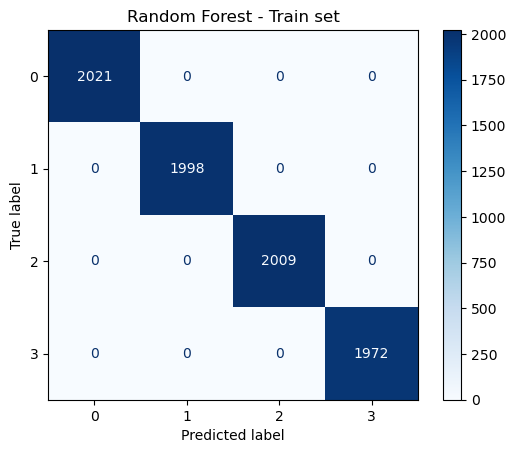

Classification Report - Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2021
           1       1.00      1.00      1.00      1998
           2       1.00      1.00      1.00      2009
           3       1.00      1.00      1.00      1972

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



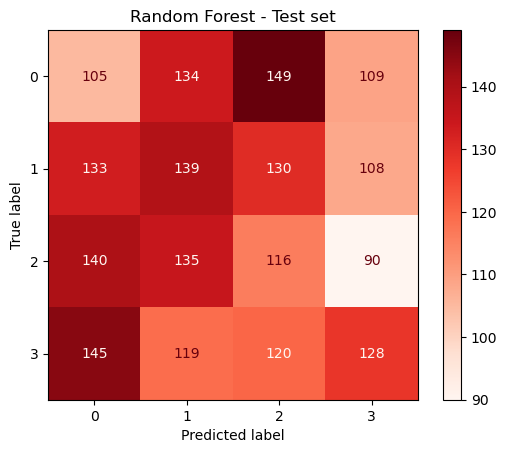

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.20      0.21      0.21       497
           1       0.26      0.27      0.27       510
           2       0.23      0.24      0.23       481
           3       0.29      0.25      0.27       512

    accuracy                           0.24      2000
   macro avg       0.25      0.24      0.24      2000
weighted avg       0.25      0.24      0.24      2000



In [59]:
# Hitung confusion matrix untuk train dan test
CMTrain = confusion_matrix(y_train, y_pred_train_mRF)
CMTest = confusion_matrix(y_test, y_pred_test_mRF)

# Plot confusion matrix untuk train
disp_train = ConfusionMatrixDisplay(confusion_matrix=CMTrain)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("Random Forest - Train set")
plt.show()

print("Classification Report - Train Set:")
print(classification_report(y_train, y_pred_train_mRF))


# Plot confusion matrix untuk test
disp_test = ConfusionMatrixDisplay(confusion_matrix=CMTest)
disp_test.plot(cmap=plt.cm.Reds)
plt.title("Random Forest - Test set")
plt.show()

print("Classification Report - Test Set:")
print(classification_report(y_test, y_pred_test_mRF))


Dari Classification Report Model Random Forest di atas, di dapatkan didapatkan nilai recall dimana mengurangi False Negative (memprediksi orang sehat (fair, good,excellent) aktualnya sakit (poor)). Nilai pada train = 1.00 dan test = 0.23. Hal ini menunjukkan bahwa model overfit.

## XGBoost

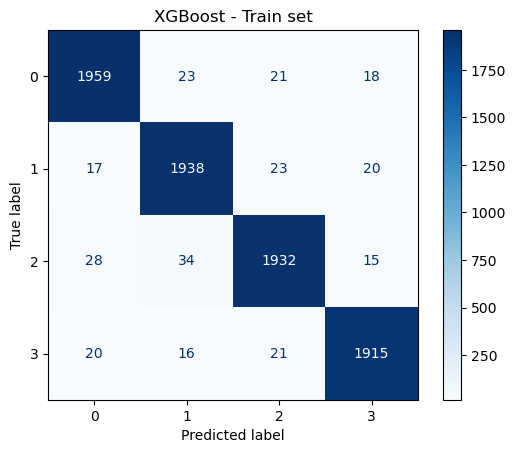

Classification Report - Train Set:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2021
           1       0.96      0.97      0.97      1998
           2       0.97      0.96      0.96      2009
           3       0.97      0.97      0.97      1972

    accuracy                           0.97      8000
   macro avg       0.97      0.97      0.97      8000
weighted avg       0.97      0.97      0.97      8000



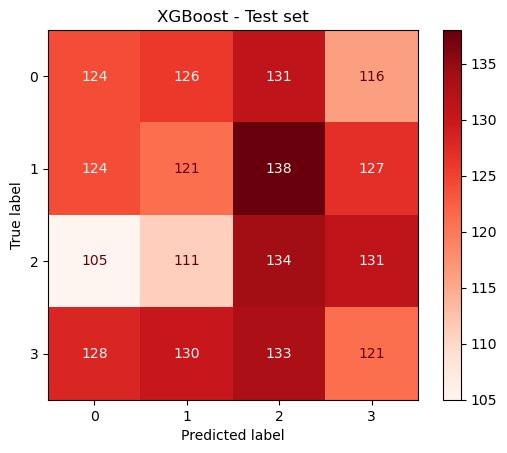

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.26      0.25      0.25       497
           1       0.25      0.24      0.24       510
           2       0.25      0.28      0.26       481
           3       0.24      0.24      0.24       512

    accuracy                           0.25      2000
   macro avg       0.25      0.25      0.25      2000
weighted avg       0.25      0.25      0.25      2000



In [60]:
# Hitung confusion matrix untuk train dan test
CMTrain = confusion_matrix(y_train, y_pred_train_mXGB)
CMTest = confusion_matrix(y_test, y_pred_test_mXGB)

# Plot confusion matrix untuk train
disp_train = ConfusionMatrixDisplay(confusion_matrix=CMTrain)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("XGBoost - Train set")
plt.show()

print("Classification Report - Train Set:")
print(classification_report(y_train, y_pred_train_mXGB))


# Plot confusion matrix untuk test
disp_test = ConfusionMatrixDisplay(confusion_matrix=CMTest)
disp_test.plot(cmap=plt.cm.Reds)
plt.title("XGBoost - Test set")
plt.show()

print("Classification Report - Test Set:")
print(classification_report(y_test, y_pred_test_mXGB))


Dari Classification Report Model XGBoost di atas, di dapatkan didapatkan nilai recall dimana mengurangi False Negative (memprediksi orang sehat (fair, good,excellent) aktualnya sakit (poor)). Nilai pada train = 0.97 dan test = 0.24. Hal ini menunjukkan bahwa model overfit.

# Hyperparameter Tuning Best Model

Berdasarkan Cross Validation score, saya memilih model KNN karena dari semua model SVM memiliki Mean Cross Validation terbesar dan KNN lebih cocok untuk dataset besar.

### Finding Best Parameter

In [61]:
# hyperparameter untuk tuning
random_search_params = ({'KNN__n_neighbors' : [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]})

random_search_params

{'KNN__n_neighbors': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]}

- n_neighbor digunakan untuk menentukan tetangga terdekat untuk pembentukan point data.

In [62]:
# proses tuning dengan random search
KNN_randomcv = RandomizedSearchCV(estimator = mModelKNN,
                                 param_distributions = random_search_params,
                                 n_iter = 50,
                                 cv = 5,
                                 scoring = 'recall_macro',
                                 n_jobs = -1,
                                 random_state = 42)


In [63]:
# training model dengan hyperparameter
KNN_randomcv.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 13 is smaller than n_iter=50. Running 13 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('PreprocessingPipe',
                                              ColumnTransformer(transformers=[('PipeNumerical',
                                                                               Pipeline(steps=[('StandardScaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Technology_Usage_Hours',
                                                                                'Social_Media_Usage_Hours',
                                                                                'Gaming_Hours',
                                                                                'Screen_Time_Hours',
                                                                                'Sleep_Hours',
                                                                                'Physical_Activity_Hours']),
                                                                              ('PipeCategorical',
                                                                               Pipeline(steps=[('EncodingOnehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Stress_Level',
                                                                                'Support_Systems_Access',
                                                                                'Work_Environment_Impact',
                                                                                'Online_Support_Usage'])])),
                                             ('KNN', KNeighborsClassifier())]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'KNN__n_neighbors': [5, 6, 7, 8, 9, 10,
                                                             11, 12, 13, 14, 15,
                                                             16, 17]},
                   random_state=42, scoring='recall_macro')

In [64]:
# parameter terbaik untuk digunakan
KNN_randomcv.best_params_

{'KNN__n_neighbors': 5}

## Create Pipeline with Hyperparameter

In [65]:
ModelInf = KNeighborsClassifier(n_neighbors = 5)

InfKNN = Pipeline([('prepospipe', PreprocessingPipeline),
                  ('Inf', ModelInf)])

Pipeline yang dibuat sudah termasuk proses features scalling, features encoding, dan memasukkan model. Metode scalling yang digunakan adalah scaler standard scaller dan metode encoding yang digunakan adalah encoder one hot. Scaler standard digunakan karena kolom berdistribusi skenormalw. Encoder one hot digunakan karena kolom berkategori nominal atau non-strata. Proses Feature scalling dan features encoding dilakukan dengan menggunakan class column transformer untuk mentransformasi data agar bisa dimasukkan ke model machine learning.

Variabel InfKNN digunakan untuk menyimpan pipeline untuk proses pemodelan decision tree dengan kolom-kolom yang sudah di scalliing dan encoding. Hyperparameter yang akan digunakan adalah n_neighbors = 5

## Training Best Model

In [66]:
# training model
InfKNN.fit(X_train, y_train)

Pipeline(steps=[('prepospipe',
                 ColumnTransformer(transformers=[('PipeNumerical',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('PipeCategorical',
                                                  Pipeline(steps=[('EncodingOnehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Stress_Level',
                                                   'Support_Systems_Access',
                                                   'Work_Environment_Impact',
                                                   'Online_Support_Usage'])])),
                ('Inf', KNeighborsClassifier())])

## Hyperparameter Tuning - Evaluation

In [67]:
# prediksi dengan set train
y_pred_train_tune = InfKNN.predict(X_train)

# prediksi dengan set test
y_pred_test_tune = InfKNN.predict(X_test)

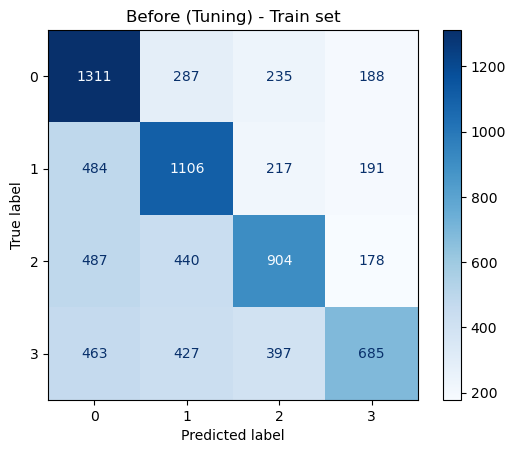

Classification Report - Train Set:
              precision    recall  f1-score   support

           0       0.48      0.65      0.55      2021
           1       0.49      0.55      0.52      1998
           2       0.52      0.45      0.48      2009
           3       0.55      0.35      0.43      1972

    accuracy                           0.50      8000
   macro avg       0.51      0.50      0.49      8000
weighted avg       0.51      0.50      0.49      8000



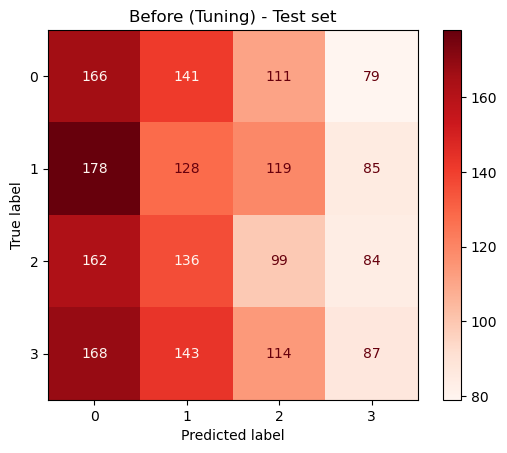

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.25      0.33      0.28       497
           1       0.23      0.25      0.24       510
           2       0.22      0.21      0.21       481
           3       0.26      0.17      0.21       512

    accuracy                           0.24      2000
   macro avg       0.24      0.24      0.24      2000
weighted avg       0.24      0.24      0.24      2000



In [68]:
# Hitung confusion matrix untuk train dan test
CMTrain = confusion_matrix(y_train, y_pred_train_mKNN)
CMTest = confusion_matrix(y_test, y_pred_test_mKNN)

# Plot confusion matrix untuk train
disp_train = ConfusionMatrixDisplay(confusion_matrix=CMTrain)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("Before (Tuning) - Train set")
plt.show()

print("Classification Report - Train Set:")
print(classification_report(y_train, y_pred_train_mKNN))


# Plot confusion matrix untuk test
disp_test = ConfusionMatrixDisplay(confusion_matrix=CMTest)
disp_test.plot(cmap=plt.cm.Reds)
plt.title("Before (Tuning) - Test set")
plt.show()

print("Classification Report - Test Set:")
print(classification_report(y_test, y_pred_test_mKNN))


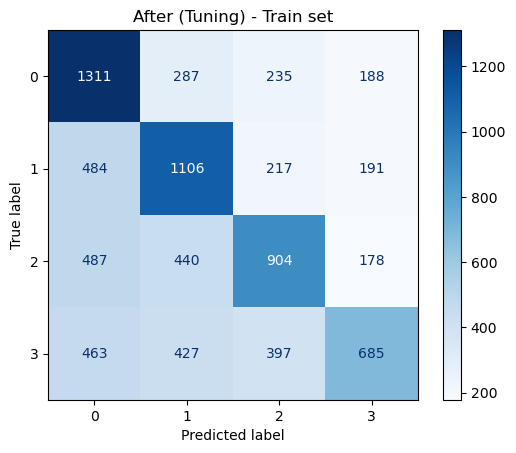

Classification Report - Train Set:
              precision    recall  f1-score   support

           0       0.48      0.65      0.55      2021
           1       0.49      0.55      0.52      1998
           2       0.52      0.45      0.48      2009
           3       0.55      0.35      0.43      1972

    accuracy                           0.50      8000
   macro avg       0.51      0.50      0.49      8000
weighted avg       0.51      0.50      0.49      8000



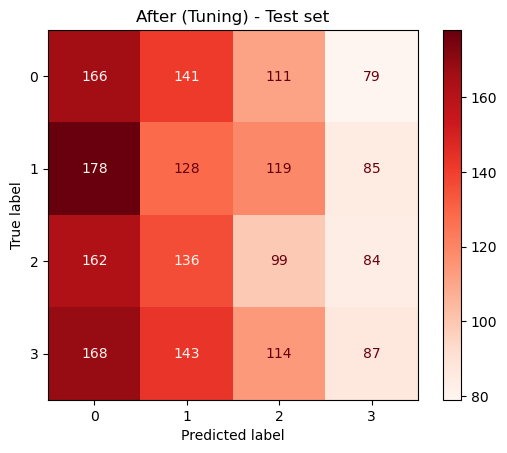

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.25      0.33      0.28       497
           1       0.23      0.25      0.24       510
           2       0.22      0.21      0.21       481
           3       0.26      0.17      0.21       512

    accuracy                           0.24      2000
   macro avg       0.24      0.24      0.24      2000
weighted avg       0.24      0.24      0.24      2000



In [69]:
# Hitung confusion matrix untuk train dan test
CMTrain = confusion_matrix(y_train, y_pred_train_tune)
CMTest = confusion_matrix(y_test, y_pred_test_tune)

# Plot confusion matrix untuk train
disp_train = ConfusionMatrixDisplay(confusion_matrix=CMTrain)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("After (Tuning) - Train set")
plt.show()

print("Classification Report - Train Set:")
print(classification_report(y_train, y_pred_train_tune))


# Plot confusion matrix untuk test
disp_test = ConfusionMatrixDisplay(confusion_matrix=CMTest)
disp_test.plot(cmap=plt.cm.Reds)
plt.title("After (Tuning) - Test set")
plt.show()

print("Classification Report - Test Set:")
print(classification_report(y_test, y_pred_test_tune))


Berdasarkan visualisai confusion matrix, classification report, dan perhitungan recall score di atas didapatkan:

- Nilai Recall model yang dibuat sangat buruk dan overfit.

# x. Model Saving

In [70]:
# menyimpan model yang akan digunakan pada inference
with open('model.pkl', 'wb') as file:
    pickle.dump(InfKNN, file)

# Model Analysis Train

In [71]:
# Membuat kolom cluster pada tabel
dfTrainKNN = X_train.copy()
dfTrainKNN['Pred'] = y_pred_train_mKNN
dfTrainKNN

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Pred
2182,29,Other,7.54,7.79,4.18,7.79,High,5.63,0.12,Yes,Neutral,No,1
5766,23,Male,3.12,6.93,4.67,8.72,High,8.28,5.26,No,Positive,No,0
2439,21,Other,7.34,3.01,2.51,6.68,High,5.66,8.94,Yes,Neutral,No,0
993,58,Male,10.25,1.93,0.28,8.09,High,8.61,3.04,No,Positive,Yes,2
7426,47,Other,6.09,1.18,0.11,3.87,Low,7.38,5.85,No,Neutral,Yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4859,60,Other,8.93,6.00,2.14,6.42,Medium,7.69,4.33,Yes,Positive,Yes,1
919,32,Other,7.24,7.25,0.77,13.88,High,5.66,8.03,No,Negative,No,3
500,43,Male,4.22,5.39,1.78,7.00,Low,4.95,5.26,No,Neutral,Yes,0
4517,27,Other,1.14,1.45,0.83,10.55,Medium,8.31,9.37,No,Negative,No,1


In [72]:
MAtrainKNN = pd.concat([
    X_train.reset_index(drop=True),        
    pd.Series(y_train.values, name='Actual'),       
    pd.Series(y_pred_train_mKNN, name='Pred')        
], axis=1)
MAtrainKNN

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Actual,Pred
0,29,Other,7.54,7.79,4.18,7.79,High,5.63,0.12,Yes,Neutral,No,1,1
1,23,Male,3.12,6.93,4.67,8.72,High,8.28,5.26,No,Positive,No,3,0
2,21,Other,7.34,3.01,2.51,6.68,High,5.66,8.94,Yes,Neutral,No,1,0
3,58,Male,10.25,1.93,0.28,8.09,High,8.61,3.04,No,Positive,Yes,3,2
4,47,Other,6.09,1.18,0.11,3.87,Low,7.38,5.85,No,Neutral,Yes,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,60,Other,8.93,6.00,2.14,6.42,Medium,7.69,4.33,Yes,Positive,Yes,3,1
7996,32,Other,7.24,7.25,0.77,13.88,High,5.66,8.03,No,Negative,No,3,3
7997,43,Male,4.22,5.39,1.78,7.00,Low,4.95,5.26,No,Neutral,Yes,0,0
7998,27,Other,1.14,1.45,0.83,10.55,Medium,8.31,9.37,No,Negative,No,3,1


In [73]:
MATrain = MAtrainKNN[(MAtrainKNN['Pred'].isin([0,1,2])) & (MAtrainKNN['Actual'].isin([3]))]  
MATrain

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Actual,Pred
1,23,Male,3.12,6.93,4.67,8.72,High,8.28,5.26,No,Positive,No,3,0
3,58,Male,10.25,1.93,0.28,8.09,High,8.61,3.04,No,Positive,Yes,3,2
8,50,Male,4.28,0.48,1.51,4.06,Medium,6.74,7.79,No,Negative,No,3,1
12,33,Male,5.51,2.62,1.29,1.27,High,5.27,4.10,Yes,Positive,No,3,2
13,48,Other,5.91,7.83,4.72,2.52,Low,4.27,3.08,No,Neutral,Yes,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7981,55,Male,3.73,1.41,4.16,12.86,Low,8.64,8.36,Yes,Positive,Yes,3,1
7984,37,Female,11.96,2.98,1.25,7.65,Medium,5.30,3.00,Yes,Positive,Yes,3,0
7991,54,Female,10.43,2.83,0.05,7.42,High,8.42,5.92,No,Negative,Yes,3,0
7995,60,Other,8.93,6.00,2.14,6.42,Medium,7.69,4.33,Yes,Positive,Yes,3,1


In [74]:
MATrain.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1287.0,40.985237,14.169127,18.00,28.000,40.00,53.000,65.00
Technology_Usage_Hours,1287.0,6.472191,3.189855,1.01,3.650,6.31,9.185,11.99
Social_Media_Usage_Hours,1287.0,4.010614,2.316568,0.00,2.100,4.01,6.045,7.99
Gaming_Hours,1287.0,2.515159,1.435013,0.00,1.295,2.50,3.740,5.00
Screen_Time_Hours,1287.0,7.875556,4.034298,1.01,4.370,7.65,11.505,15.00
Sleep_Hours,1287.0,6.478011,1.454935,4.00,5.235,6.45,7.740,9.00
Physical_Activity_Hours,1287.0,5.048687,2.883601,0.00,2.585,5.05,7.510,10.00
Pred,1287.0,0.948718,0.816155,0.00,0.000,1.00,2.000,2.00


## Rata-rata 'Sleep_Hours' tiap kategori umur Train set

In [75]:
# Fungsi kategori usia
def categorize_age(age):
    if 18 <= age <= 19:
        return "10's"
    elif 20 <= age <= 29:
        return "20's"
    elif 30 <= age <= 39:
        return "30's"
    elif 40 <= age <= 49:
        return "40's"
    elif 50 <= age <= 59:
        return "50's"
    elif 60 <= age <= 69:
        return "60's"
    else:
        return 'Other'

# Buat kolom AgeGroup di MATrain
MATrain['AgeGroup'] = MATrain['Age'].apply(categorize_age)

# Filter hanya AgeGroup yang valid
AgeOrder = ["10's", "20's", "30's", "40's", "50's", "60's"]
filtered = MATrain[MATrain['AgeGroup'].isin(AgeOrder)]

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/1361383696.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MATrain['AgeGroup'] = MATrain['Age'].apply(categorize_age)


/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/810363991.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='AgeGroup', y='Sleep_Hours', data=avg_sleep, palette='Purples', order=AgeOrder)


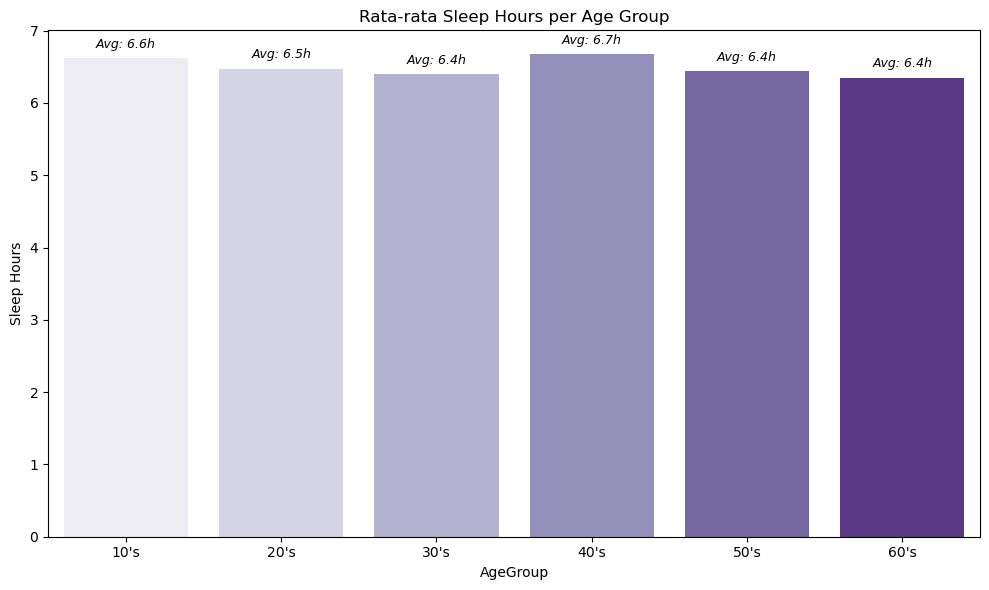

In [76]:
# Hitung rata-rata Sleep_Hours per AgeGroup
avg_sleep = (
    filtered.groupby('AgeGroup')['Sleep_Hours']
    .mean()
    .reindex(AgeOrder)
    .reset_index()
)

# Plot Sleep_Hours
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='AgeGroup', y='Sleep_Hours', data=avg_sleep, palette='Purples', order=AgeOrder)
ax.set_title('Rata-rata Sleep Hours per Age Group')
ax.set_ylabel('Sleep Hours')

# Tambahkan anotasi rata-rata Sleep_Hours di atas bar
for i, row in avg_sleep.iterrows():
    if not pd.isna(row['Sleep_Hours']):  # Hindari error jika ada NaN
        ax.text(i, row['Sleep_Hours'] + 0.1, f"Avg: {row['Sleep_Hours']:.1f}h", 
                ha='center', va='bottom', fontsize=9, color='black', style='italic')

plt.tight_layout()
plt.show()


## Rata-rata 'Physical_Activity_Hours' tiap kategori umur Train set

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3284668194.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='AgeGroup', y='Physical_Activity_Hours', data=avg_activity, palette='Oranges', order=AgeOrder)


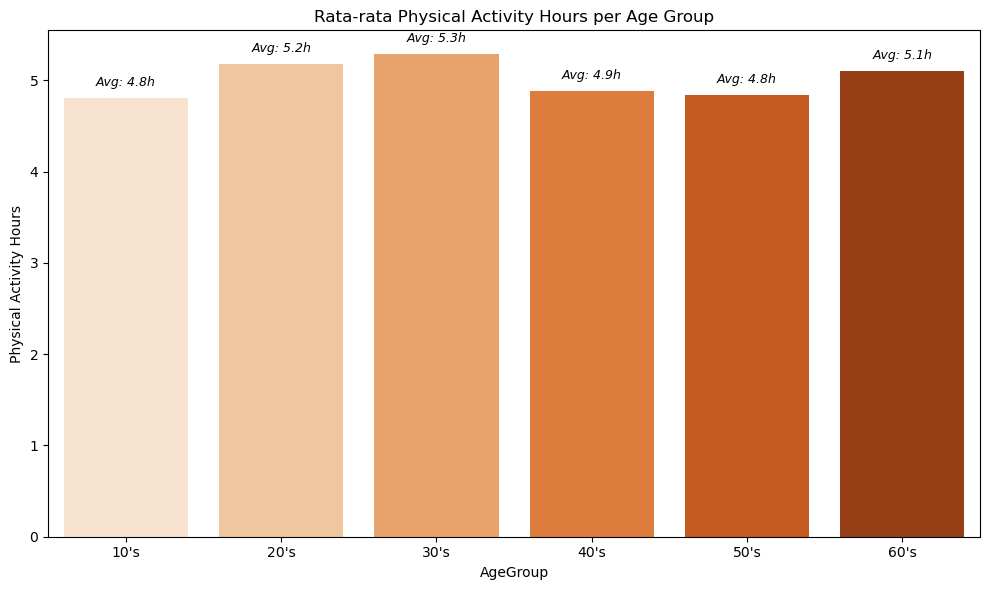

In [77]:
# Plot 
avg_activity = (
    filtered.groupby('AgeGroup')['Physical_Activity_Hours']
    .mean()
    .reindex(AgeOrder)
    .reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='AgeGroup', y='Physical_Activity_Hours', data=avg_activity, palette='Oranges', order=AgeOrder)
ax.set_title('Rata-rata Physical Activity Hours per Age Group')
ax.set_ylabel('Physical Activity Hours')

# Tambahkan anotasi rata-rata Physical_Activity_Hours di atas bar
for i, row in avg_activity.iterrows():
    ax.text(i, row['Physical_Activity_Hours'] + 0.1, f"Avg: {row['Physical_Activity_Hours']:.1f}h", 
            ha='center', va='bottom', fontsize=9, color='black', style='italic')

plt.tight_layout()
plt.show()


## Rata-rata 'Gaming_Hours' tiap kategori umur Train set

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/1587895839.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='AgeGroup', y='Gaming_Hours', data=avg_gaming, palette='Greens', order=AgeOrder)


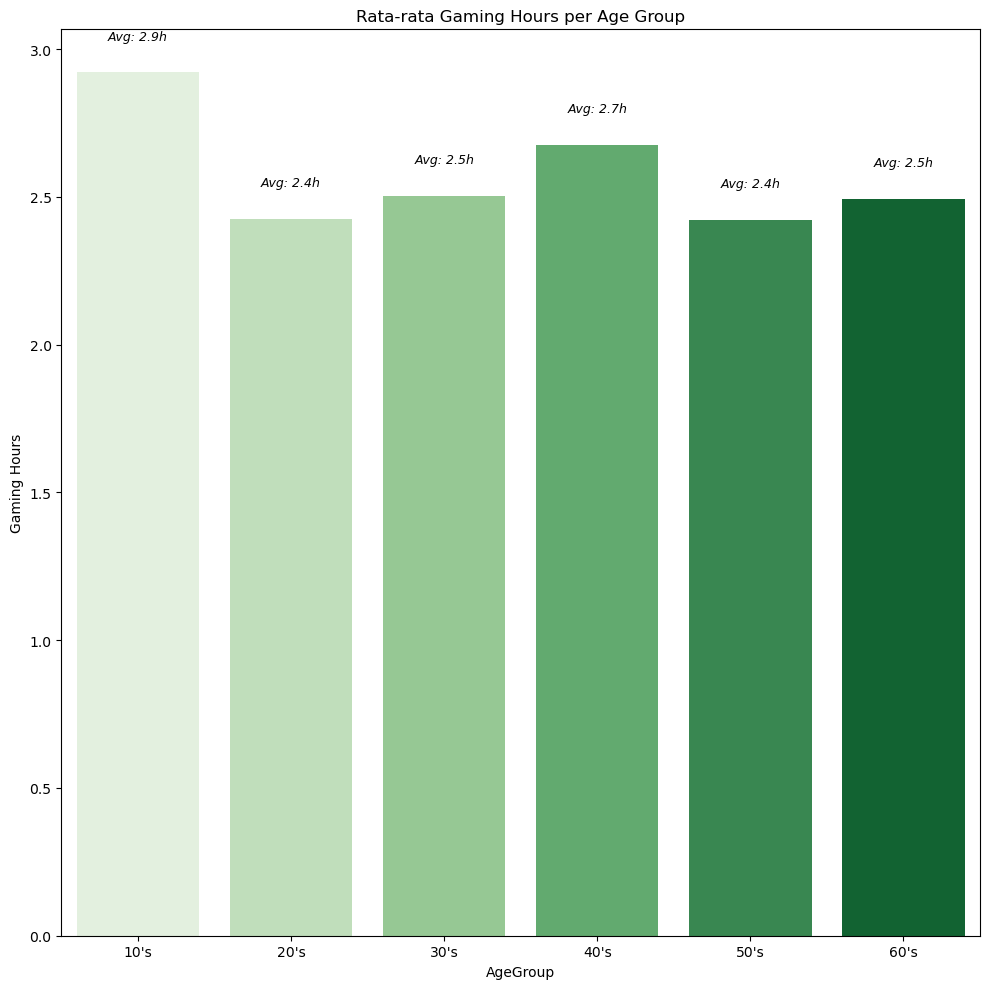

In [78]:
# Hitung rata-rata dan jumlah untuk Gaming_Hours
avg_gaming = (
    filtered.groupby('AgeGroup')['Gaming_Hours']
    .mean()
    .reindex(AgeOrder)
    .reset_index()
)

# Plot Gaming_Hours
plt.figure(figsize=(10, 10))
ax = sns.barplot(x='AgeGroup', y='Gaming_Hours', data=avg_gaming, palette='Greens', order=AgeOrder)
ax.set_title('Rata-rata Gaming Hours per Age Group')
ax.set_ylabel('Gaming Hours')

# Tambahkan anotasi rata-rata Gaming_Hours di atas bar
for i, row in avg_gaming.iterrows():
    ax.text(i, row['Gaming_Hours'] + 0.1, f"Avg: {row['Gaming_Hours']:.1f}h",
            ha='center', va='bottom', fontsize=9, color='black', style='italic')

plt.tight_layout()
plt.show()


Model cenderung salah memprediksi pada Train set ketika rata-rata 'Sleep_Hours' = 6.7 jam terbesar pada kategori umur 40's, rata-rata 'Physical_Activity_Hours' = 5.3 jam terbesar pada kategori umur 30's, dan 'Gaming_Hours' = 2.9 jam terbesar pada kategori umur 10's

# Model Analysis Test

In [79]:
# Membuat kolom cluster pada tabel
dfTestKNN = X_test.copy()
dfTestKNN['Pred'] = y_pred_test_mKNN
dfTestKNN

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Pred
8793,53,Female,9.98,3.05,2.73,8.08,High,5.92,7.90,Yes,Positive,No,1
1122,26,Male,8.28,1.96,2.90,10.05,Low,6.62,1.18,Yes,Positive,No,0
1283,50,Other,11.65,3.60,3.75,12.59,High,4.70,3.59,Yes,Negative,Yes,3
9318,52,Other,2.60,0.82,1.58,11.90,Low,4.52,6.31,No,Positive,Yes,3
7765,50,Male,7.59,2.09,1.82,3.96,Medium,4.65,0.27,No,Positive,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7142,44,Male,7.89,6.51,2.99,11.25,Medium,5.67,4.77,Yes,Negative,No,1
8826,52,Female,4.95,1.90,3.15,1.74,High,6.07,0.51,No,Positive,Yes,0
4553,29,Female,9.92,5.97,2.62,1.74,Low,4.88,7.68,No,Positive,Yes,3
5795,39,Other,3.73,1.90,0.75,2.34,Medium,8.64,2.83,No,Negative,No,0


In [80]:
MAtestKNN = pd.concat([
    X_train.reset_index(drop=True),        
    pd.Series(y_test.values, name='Actual'),       
    pd.Series(y_pred_test_mKNN, name='Pred')        
], axis=1)
MAtestKNN

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Actual,Pred
0,29,Other,7.54,7.79,4.18,7.79,High,5.63,0.12,Yes,Neutral,No,0,1.0
1,23,Male,3.12,6.93,4.67,8.72,High,8.28,5.26,No,Positive,No,3,0.0
2,21,Other,7.34,3.01,2.51,6.68,High,5.66,8.94,Yes,Neutral,No,2,3.0
3,58,Male,10.25,1.93,0.28,8.09,High,8.61,3.04,No,Positive,Yes,2,3.0
4,47,Other,6.09,1.18,0.11,3.87,Low,7.38,5.85,No,Neutral,Yes,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,60,Other,8.93,6.00,2.14,6.42,Medium,7.69,4.33,Yes,Positive,Yes,NaN,NaN
7996,32,Other,7.24,7.25,0.77,13.88,High,5.66,8.03,No,Negative,No,NaN,NaN
7997,43,Male,4.22,5.39,1.78,7.00,Low,4.95,5.26,No,Neutral,Yes,NaN,NaN
7998,27,Other,1.14,1.45,0.83,10.55,Medium,8.31,9.37,No,Negative,No,NaN,NaN


In [81]:
MATest = MAtestKNN[(MAtestKNN['Pred'].isin([0,1,2])) & (MAtestKNN['Actual'].isin([3]))]  
MATest

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Actual,Pred
1,23,Male,3.12,6.93,4.67,8.72,High,8.28,5.26,No,Positive,No,3,0.0
4,47,Other,6.09,1.18,0.11,3.87,Low,7.38,5.85,No,Neutral,Yes,3,0.0
6,64,Male,10.67,4.51,0.75,5.90,Medium,4.36,7.94,Yes,Negative,No,3,2.0
15,39,Other,7.63,3.60,3.37,1.18,Medium,4.19,3.99,Yes,Positive,Yes,3,0.0
20,62,Male,2.06,2.40,4.38,11.32,Medium,4.46,7.54,Yes,Neutral,No,3,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1968,36,Other,9.68,1.64,3.60,5.13,Low,7.96,3.09,Yes,Negative,Yes,3,0.0
1969,23,Other,1.37,6.93,3.84,10.75,High,4.61,7.78,Yes,Positive,No,3,0.0
1984,21,Male,2.90,3.64,3.90,7.01,High,6.85,1.99,No,Positive,Yes,3,0.0
1994,22,Other,6.55,3.70,3.95,8.31,Low,6.15,1.59,No,Positive,No,3,2.0


In [82]:
# Buat subset data MATest
MATest = MAtestKNN[(MAtestKNN['Pred'].isin([0, 1, 2])) & (MAtestKNN['Actual'].isin([3]))]

# Fungsi kategori usia
def categorize_age(age):
    if 18 <= age <= 19:
        return "10's"
    elif 20 <= age <= 29:
        return "20's"
    elif 30 <= age <= 39:
        return "30's"
    elif 40 <= age <= 49:
        return "40's"
    elif 50 <= age <= 59:
        return "50's"
    elif 60 <= age <= 69:
        return "60's"
    else:
        return 'Other'

# Buat kolom AgeGroup di MATest
MATest['AgeGroup'] = MATest['Age'].apply(categorize_age)

# Filter hanya AgeGroup yang valid
AgeOrder = ["10's", "20's", "30's", "40's", "50's", "60's"]
filtered = MATest[MATest['AgeGroup'].isin(AgeOrder)]


/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3613764501.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MATest['AgeGroup'] = MATest['Age'].apply(categorize_age)


## Rata-rata 'Sleep_Hours' tiap kategori umur Test set

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/1025642392.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='AgeGroup', y='Sleep_Hours', data=avg_sleep, palette='Purples', order=AgeOrder)


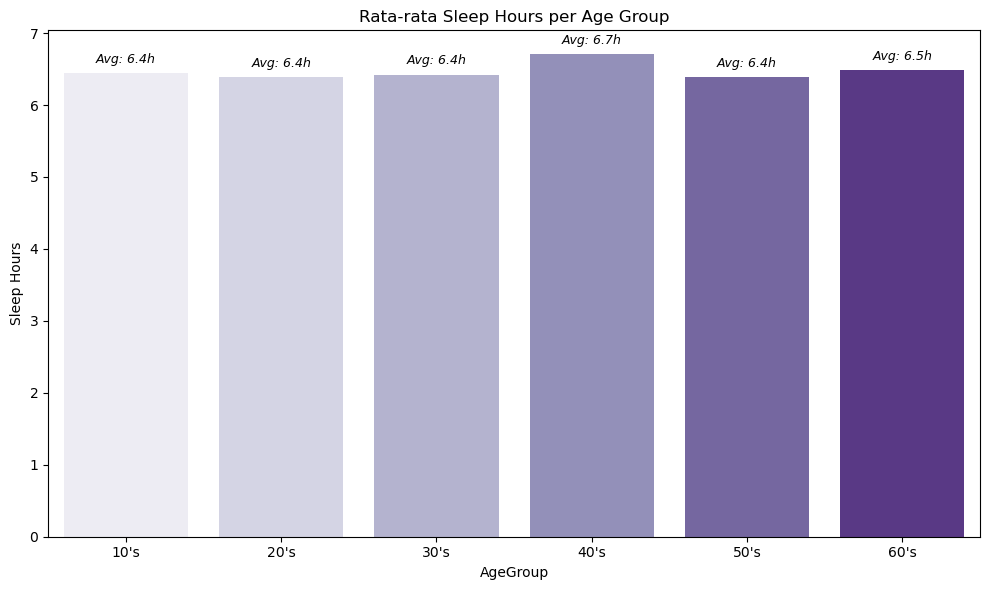

In [83]:
# Hitung rata-rata Sleep_Hours per AgeGroup
avg_sleep = (
    filtered.groupby('AgeGroup')['Sleep_Hours']
    .mean()
    .reindex(AgeOrder)
    .reset_index()
)

# Plot Sleep_Hours
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='AgeGroup', y='Sleep_Hours', data=avg_sleep, palette='Purples', order=AgeOrder)
ax.set_title('Rata-rata Sleep Hours per Age Group')
ax.set_ylabel('Sleep Hours')

# Tambahkan anotasi rata-rata Sleep_Hours di atas bar
for i, row in avg_sleep.iterrows():
    if not pd.isna(row['Sleep_Hours']):
        ax.text(i, row['Sleep_Hours'] + 0.1, f"Avg: {row['Sleep_Hours']:.1f}h", 
                ha='center', va='bottom', fontsize=9, color='black', style='italic')

plt.tight_layout()
plt.show()

## Rata-rata 'Physical_Activity_Hours' tiap kategori umur Test set

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/1708721369.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='AgeGroup', y='Physical_Activity_Hours', data=avg_activity, palette='Oranges', order=AgeOrder)


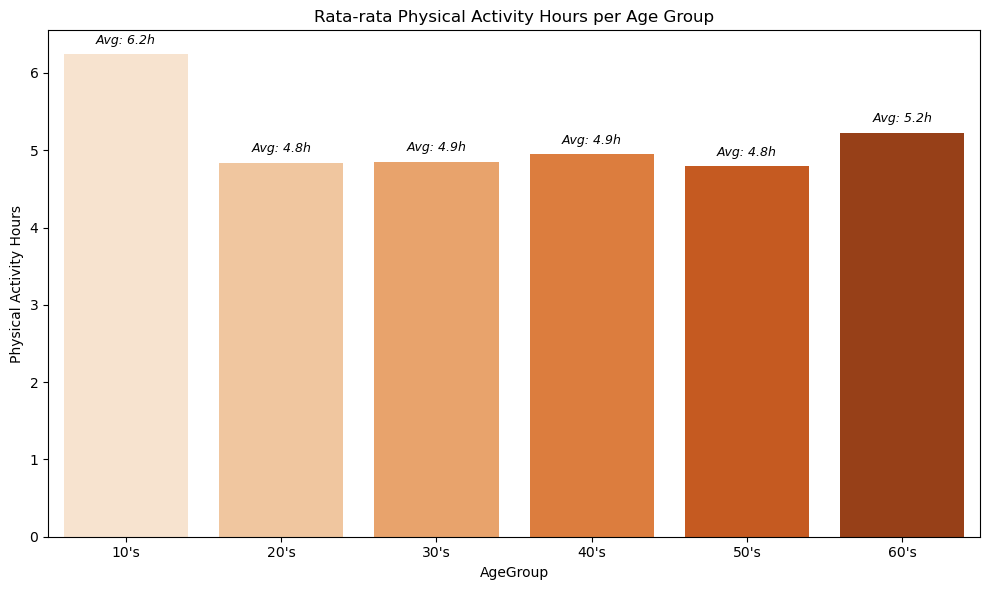

In [84]:
# Hitung rata-rata Physical_Activity_Hours per AgeGroup
avg_activity = (
    filtered.groupby('AgeGroup')['Physical_Activity_Hours']
    .mean()
    .reindex(AgeOrder)
    .reset_index()
)

# Plot Physical_Activity_Hours
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='AgeGroup', y='Physical_Activity_Hours', data=avg_activity, palette='Oranges', order=AgeOrder)
ax.set_title('Rata-rata Physical Activity Hours per Age Group')
ax.set_ylabel('Physical Activity Hours')

# Tambahkan anotasi rata-rata Physical_Activity_Hours di atas bar
for i, row in avg_activity.iterrows():
    if not pd.isna(row['Physical_Activity_Hours']):
        ax.text(i, row['Physical_Activity_Hours'] + 0.1, f"Avg: {row['Physical_Activity_Hours']:.1f}h", 
                ha='center', va='bottom', fontsize=9, color='black', style='italic')

plt.tight_layout()
plt.show()


## Rata-rata 'Gaming_Hours' tiap kategori umur Test set

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15941/3374184179.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='AgeGroup', y='Gaming_Hours', data=avg_gaming, palette='Blues', order=AgeOrder)


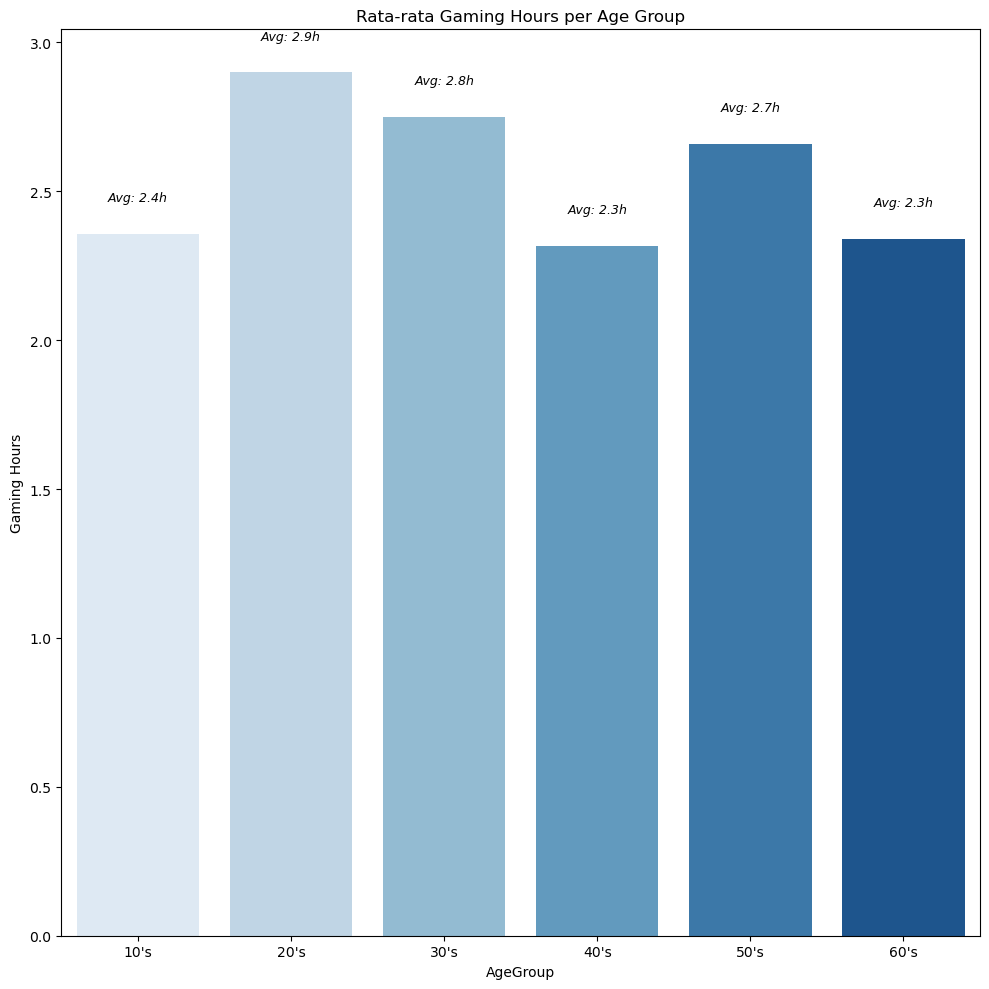

In [85]:
# Hitung rata-rata Gaming_Hours per AgeGroup
avg_gaming = (
    filtered.groupby('AgeGroup')['Gaming_Hours']
    .mean()
    .reindex(AgeOrder)
    .reset_index()
)

# Plot Gaming_Hours
plt.figure(figsize=(10, 10))
ax = sns.barplot(x='AgeGroup', y='Gaming_Hours', data=avg_gaming, palette='Blues', order=AgeOrder)
ax.set_title('Rata-rata Gaming Hours per Age Group')
ax.set_ylabel('Gaming Hours')

# Tambahkan anotasi rata-rata Gaming_Hours di atas bar
for i, row in avg_gaming.iterrows():
    if not pd.isna(row['Gaming_Hours']):
        ax.text(i, row['Gaming_Hours'] + 0.1, f"Avg: {row['Gaming_Hours']:.1f}h", 
                ha='center', va='bottom', fontsize=9, color='black', style='italic')

plt.tight_layout()
plt.show()


Model cenderung salah memprediksi pada Test set ketika rata-rata 'Sleep_Hours' = 6.7 jam terbesar pada kategori umur 40's, rata-rata 'Physical_Activity_Hours' = 6.2 jam terbesar pada kategori umur 10's, dan 'Gaming_Hours' = 2.9 jam terbesar pada kategori umur 20's

# xi. Conclusion

## Kesimpulan

Model terbaik yang saya buat overfit dengan nilai recall pada Train set = 0.35 dan Test set = 0.17. Model ini berkemungkinan besar dapat menyebabkan kesalahan pada prediksi. Hal ini terjadi dapat disebabkan data yang digunakan tidak mempunyai suatu pola yang spesifik yang bisa dipelajari oleh model atau proses feature engineering yang kurang optimal. Maka dari itu model yang dibuat memiliki performa yang sangat buruk dalam membantu diagnosa kesehatan mental.

## Recommendation

Pada saat melakukan Hyperparameter tuning sebaiknya menggunakan Grid Search karena metode tersebut dapat menghasilkan model yang lebih optimal dibanding Randomized Search. Grid Search dapat menghasilkan model yang lebih optimal dikarenakan mencoba semua kombinasi hyperparameter, sedangkan Randomized Search hanya mencoba kombinasi hyperparameter menggunakan sampel yang ditentukan kombinasinya (n_iter). Atau dapat mengelompokkan Mental Health Status menjadi 2 kategori saja seperti (Poor & Fair) = 1, (Good & Excellent) = 0